<a href="https://colab.research.google.com/github/DoggoWoofWoof/Implementation-of-GANS/blob/main/v2/PCA_vs_Histogram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mtcnn
!pip install facenet_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

In [ ]:
from __future__ import print_function, division

import os
import sys
import datetime
import glob
import pickle

import numpy as np
import scipy
import cv2
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from keras.models import load_model

from sklearn.utils import shuffle

from skimage.metrics import structural_similarity as ssim

# TensorFlow and Keras imports
from tensorflow.keras.layers import (
    Input, Dense, Reshape, Flatten, Dropout, Concatenate,
    BatchNormalization, Activation, ZeroPadding2D, LeakyReLU,
    UpSampling2D, Conv2D
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

import natsort

In [ ]:
# Install Git
!apt-get install -y git

# Clone the repository with sparse checkout enabled
!git clone --depth 1 --filter=blob:none --sparse https://github.com/DoggoWoofWoof/Implementation-of-GANS.git

# Navigate to the repository directory and checkout the specific folders
%cd Implementation-of-GANS
!git sparse-checkout init --cone
!git sparse-checkout set "Sketch2Face Implementations/Dataset for Sketch2Face/combined (grey)"

# Move the folders to the parent directory
!mv "Sketch2Face Implementations/Dataset for Sketch2Face/combined (grey)" ../combined

# Navigate back to the parent directory
%cd ..

# Remove the cloned repository
!rm -rf Implementation-of-GANS

# Verify the contents of the combined folder and CUHK folder
!ls combined

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.11).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
Cloning into 'Implementation-of-GANS'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 62 (delta 2), reused 52 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 4.41 MiB | 8.43 MiB/s, done.
Resolving deltas: 100% (2/2), done.
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 1.17 KiB | 601.00 KiB/s, done.
/content/Implementation-of-GANS
remote: Enumerating objects: 5287, done.
remote: Counting objects: 100% (5287/5287), done.
remote: Compressing objects: 100% (5287/5287), done.

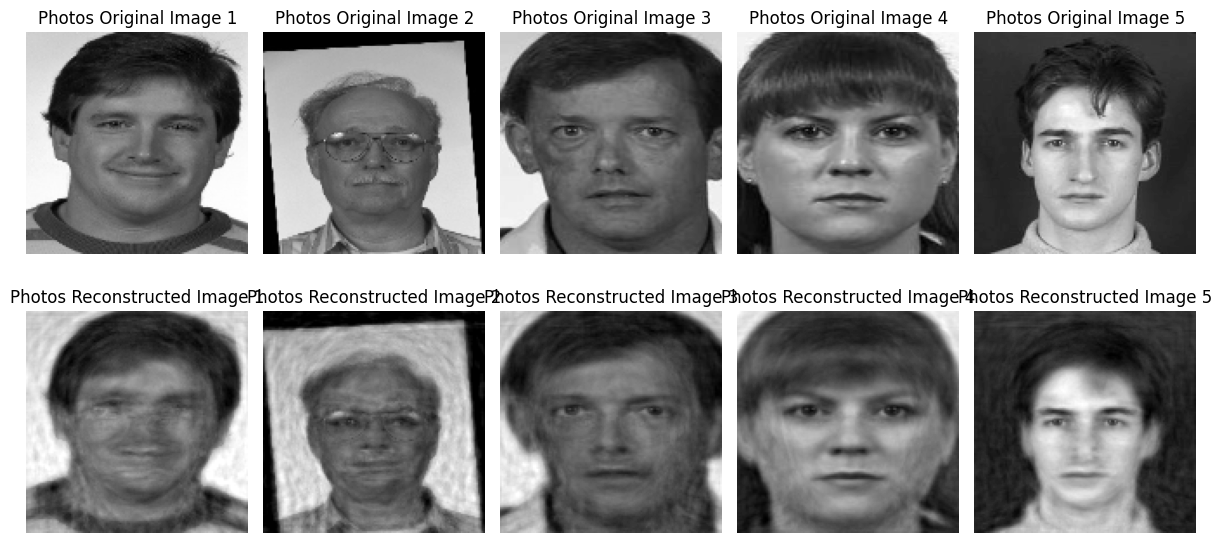

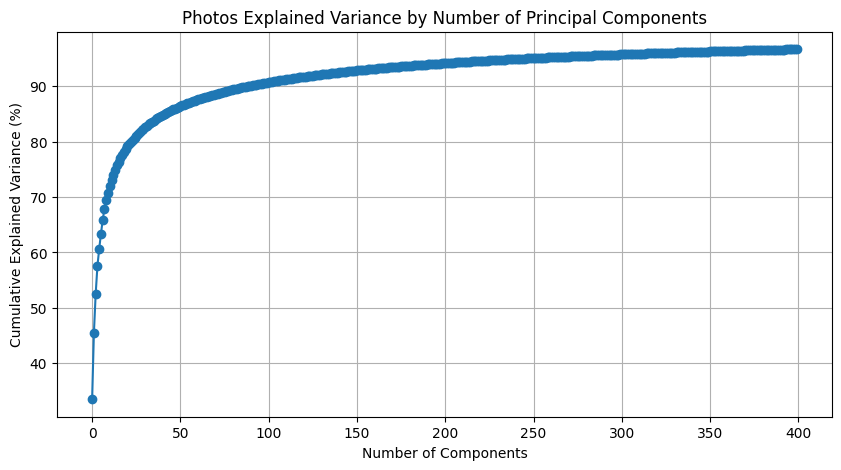

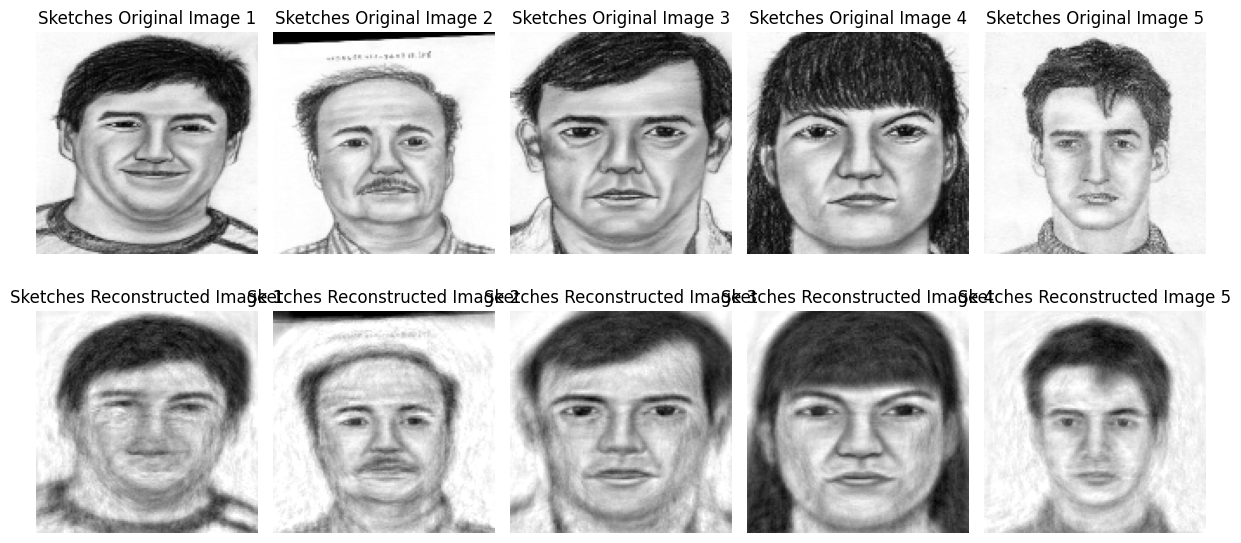

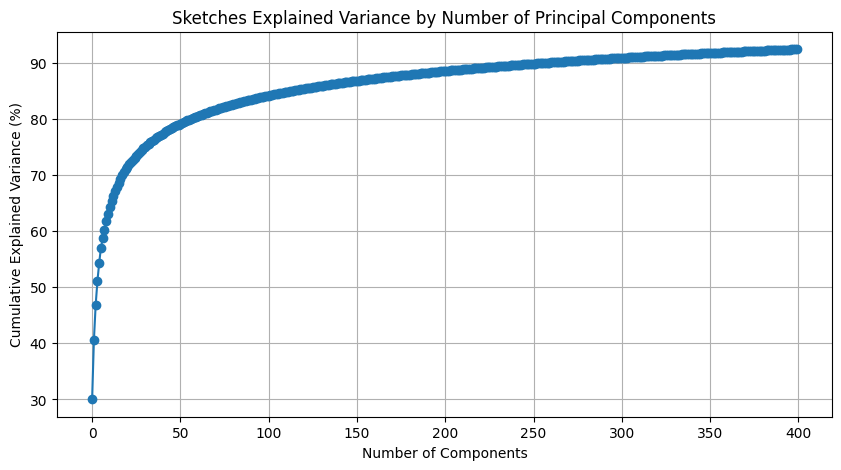

In [ ]:
import cv2
import numpy as np
import os
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Function to load, resize, and flatten images for PCA
def load_and_flatten_images(image_folder, target_size):
    images = []
    filenames = []
    for filename in os.listdir(image_folder):
        if filename.endswith('.png') or filename.endswith('.jpg'):
            img = cv2.imread(os.path.join(image_folder, filename), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                # Resize the image to the target size
                resized_img = cv2.resize(img, target_size)
                # Flatten the resized image
                images.append(resized_img.flatten())
                filenames.append(filename)
    return np.array(images), filenames

# Function to apply PCA, reconstruct images, and display results
def apply_pca_and_display(images, n_components, target_size, title_prefix):
    # Apply PCA for dimensionality reduction
    pca = PCA(n_components=n_components)
    reduced_features = pca.fit_transform(images)

    # Select the subset of images to be displayed
    num_images = min(5, len(images))  # Display up to 5 images
    indices_to_display = list(range(num_images))

    # Reconstruct the selected images from the reduced features
    reconstructed_images = pca.inverse_transform(reduced_features)
    reconstructed_images = [reconstructed_images[i].reshape(target_size) for i in range(len(reconstructed_images))]

    # Display original and reconstructed images
    plt.figure(figsize=(12, 6))
    for i in indices_to_display:
        # Display the original image
        plt.subplot(2, num_images, i + 1)
        plt.title(f'{title_prefix} Original Image {i + 1}')
        plt.imshow(images[i].reshape(target_size), cmap='gray')
        plt.axis('off')

        # Display the reconstructed image
        plt.subplot(2, num_images, num_images + i + 1)
        plt.title(f'{title_prefix} Reconstructed Image {i + 1}')
        plt.imshow(np.clip(reconstructed_images[i], 0, 255).astype(np.uint8), cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Plot the explained variance ratio
    plt.figure(figsize=(10, 5))
    plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, marker='o')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance (%)')
    plt.title(f'{title_prefix} Explained Variance by Number of Principal Components')
    plt.grid(True)
    plt.show()

# Define the target size for resizing images (e.g., 128x128)
target_size = (128, 128)
n_components = 400  # Adjust based on the desired level of reconstruction

# Define the paths to the image datasets
photo_folder = '/content/combined/photos'  # Update with your path
sketch_folder = '/content/combined/sketches'  # Update with your path

# Process photos
photos, photo_filenames = load_and_flatten_images(photo_folder, target_size)
apply_pca_and_display(photos, n_components, target_size, 'Photos')

# Process sketches
sketches, sketch_filenames = load_and_flatten_images(sketch_folder, target_size)
apply_pca_and_display(sketches, n_components, target_size, 'Sketches')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: -23.0943] [G loss: -15.3962]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step


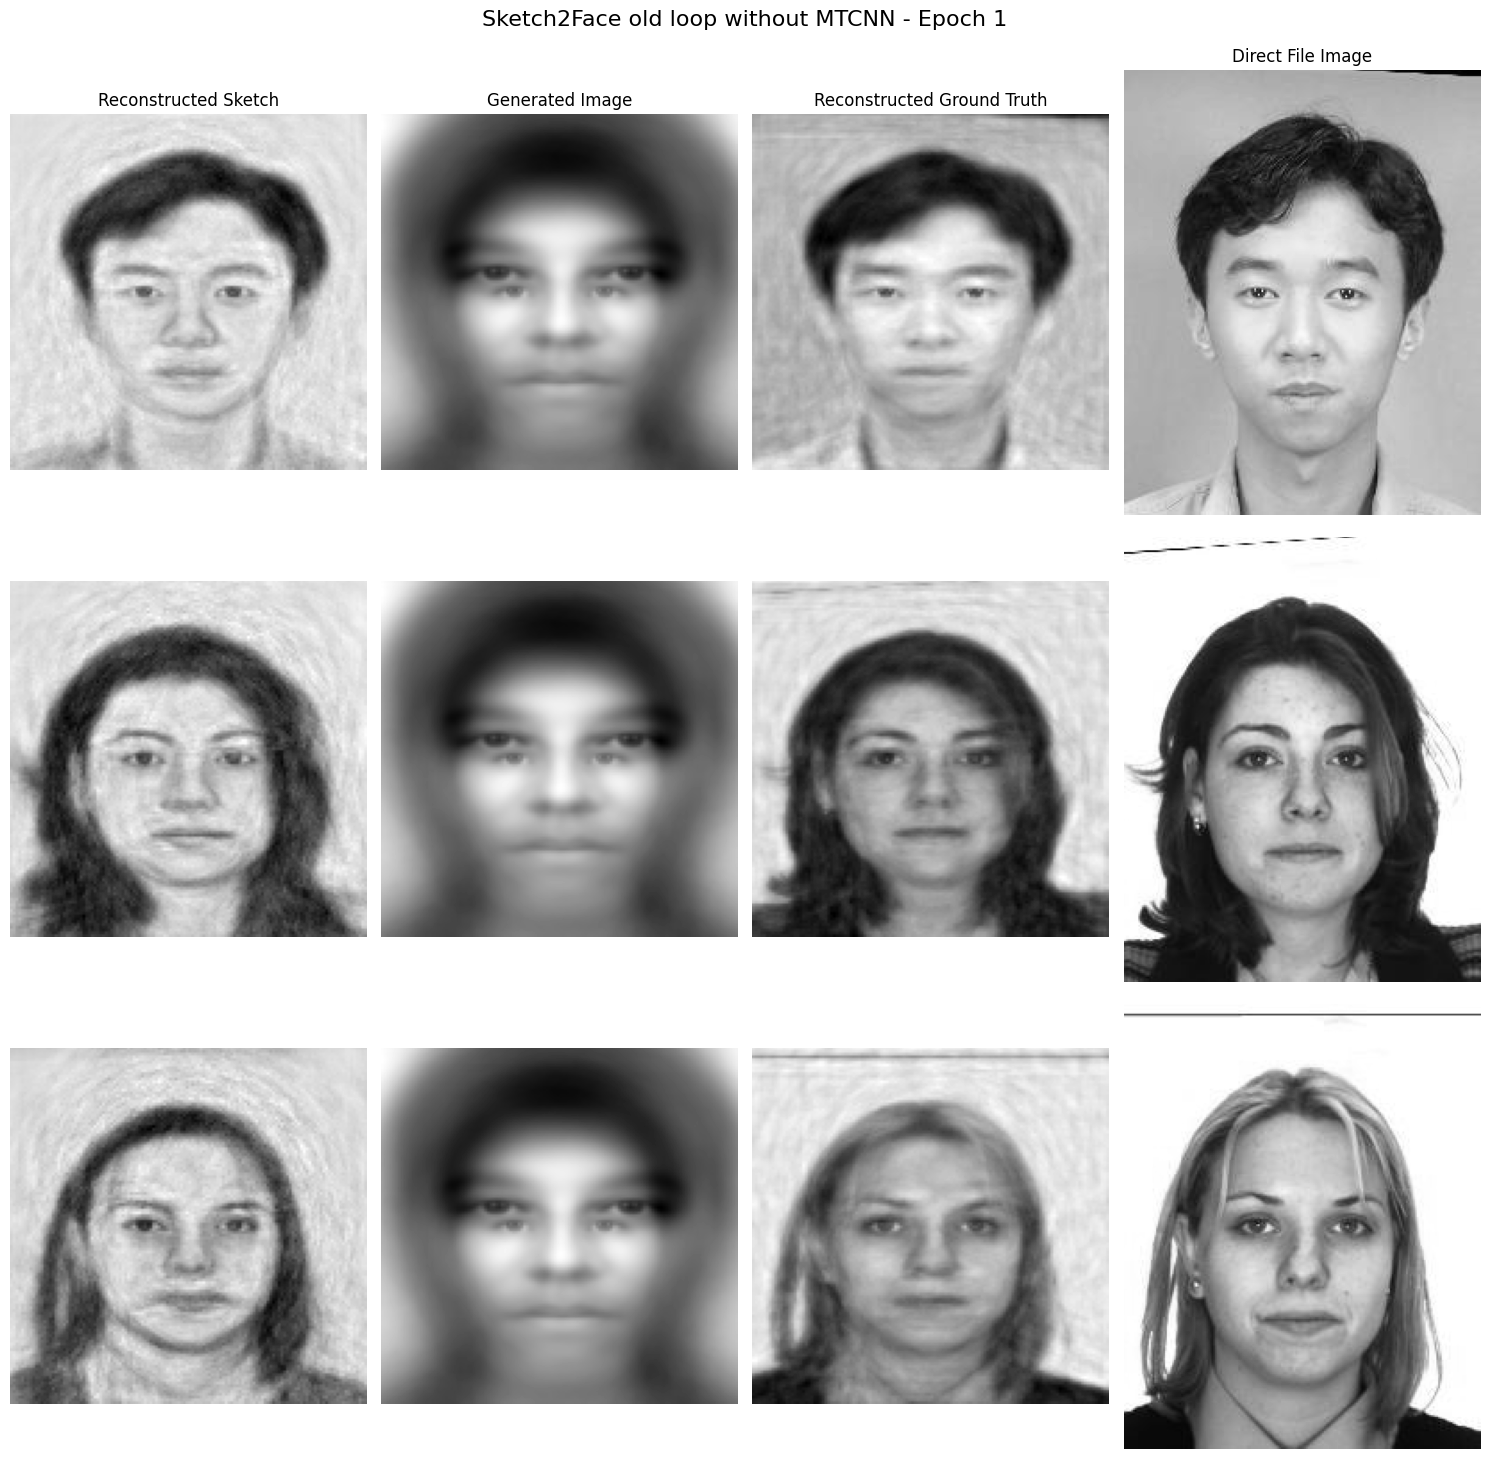

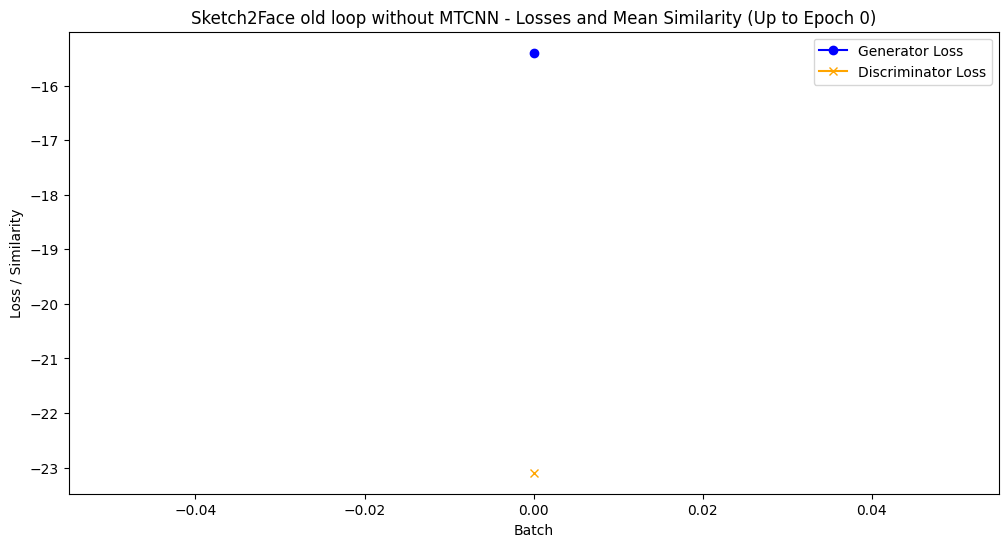

Plot saved at: Models/Sketch2Face old loop without MTCNN/metrics/metrics_epoch_0.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np
import cv2
import os
from sklearn.decomposition import PCA

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define paths to the sketch and photo directories
sketch_folder = '/content/combined/sketches'
photo_folder = '/content/combined/photos'

# Define the target size for resizing images (e.g., 128x128)
target_size = (128, 128)

def load_and_preprocess_images(image_folder, target_size):
    images = []
    filenames = []
    for filename in os.listdir(image_folder):
        if filename.endswith('.png') or filename.endswith('.jpg'):
            img = cv2.imread(os.path.join(image_folder, filename), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                # Resize the image to the target size
                resized_img = cv2.resize(img, target_size)
                # Flatten the resized image
                images.append(resized_img.flatten())
                filenames.append(filename)
    return np.array(images), filenames

# Load and preprocess sketches and photos
sketch_images, sketch_filenames = load_and_preprocess_images(sketch_folder, target_size)
photo_images, photo_filenames = load_and_preprocess_images(photo_folder, target_size)

# Apply PCA for dimensionality reduction
n_components = 400  # Adjust based on the desired level of reconstruction
sketch_pca = PCA(n_components=n_components)
reduced_sketch_vectors = sketch_pca.fit_transform(sketch_images)

photo_pca = PCA(n_components=n_components)
reduced_photo_vectors = photo_pca.fit_transform(photo_images)

# Parameters
input_dim = reduced_sketch_vectors.shape[1]  # Reduced dimension for sketch features
output_dim = reduced_photo_vectors.shape[1]  # PCA components for photo features

# Wasserstein loss function
def wasserstein_loss(y_true, y_pred):
    return tf.reduce_mean(y_true * y_pred)

# Generator Model using U-Net architecture
def build_unet_generator(input_dim, output_dim):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(512, activation=None)(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Reshape((16, 16, 2))(x)

    # Downsampling path
    conv1 = layers.Conv2D(64, kernel_size=3, padding='same')(x)
    conv1 = layers.LeakyReLU(alpha=0.2)(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(128, kernel_size=3, padding='same')(pool1)
    conv2 = layers.LeakyReLU(alpha=0.2)(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    # Bottleneck
    bottleneck = layers.Conv2D(256, kernel_size=3, padding='same')(pool2)
    bottleneck = layers.LeakyReLU(alpha=0.2)(bottleneck)
    bottleneck = layers.BatchNormalization()(bottleneck)

    # Upsampling path
    up2 = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same')(bottleneck)
    up2 = layers.concatenate([up2, conv2])
    up2 = layers.Conv2D(128, kernel_size=3, padding='same')(up2)
    up2 = layers.LeakyReLU(alpha=0.2)(up2)
    up2 = layers.BatchNormalization()(up2)

    up1 = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same')(up2)
    up1 = layers.concatenate([up1, conv1])
    up1 = layers.Conv2D(64, kernel_size=3, padding='same')(up1)
    up1 = layers.LeakyReLU(alpha=0.2)(up1)
    up1 = layers.BatchNormalization()(up1)

    outputs = layers.Conv2DTranspose(2, kernel_size=3, padding='same')(up1)
    outputs = layers.Flatten()(outputs)
    outputs = layers.Dense(output_dim, activation='tanh')(outputs)

    return Model(inputs, outputs)

# Discriminator Model
def build_wgan_discriminator(input_dim):
    model = Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(256, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(128, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(1, activation=None)  # No activation for WGAN
    ])
    return model

# Create the models
generator = build_unet_generator(input_dim, output_dim)
discriminator = build_wgan_discriminator(output_dim)

# Optimizer
opt = Adam(learning_rate=2e-4, beta_1=0.5)

# Compile Discriminator with WGAN loss
discriminator.compile(loss=wasserstein_loss, optimizer=opt)

# Build GAN Model
discriminator.trainable = False
gan_input = layers.Input(shape=(input_dim,))
generated_features = generator(gan_input)
gan_output = discriminator(generated_features)

gan = Model(gan_input, gan_output)
gan.compile(loss=wasserstein_loss, optimizer=opt)


def summarize_performance(step, g_model, d_model, data, model_name, target_dir='', n_samples=3):
    """
    Summarize the performance by generating sample outputs and saving models.

    Parameters:
    - step: Current epoch number.
    - g_model: Generator model.
    - d_model: Discriminator model.
    - data: Tuple of (sketch_vectors, photo_vectors, photo_filenames).
    - model_name: Name of the model for saving.
    - target_dir: Directory to save outputs.
    - n_samples: Number of samples to generate.
    """
    # Unpack data
    sketch_vectors, photo_vectors, photo_filenames = data

    # Select random samples
    idx = np.random.randint(0, len(sketch_vectors), n_samples)
    selected_sketches = sketch_vectors[idx]
    selected_real_photos = photo_vectors[idx]
    selected_filenames = [photo_filenames[i] for i in idx]

    # Generate fake features
    fake_features = g_model.predict(selected_sketches)

    # Reconstruct images from features
    reconstructed_images = photo_pca.inverse_transform(fake_features)

    # Reconstruct original sketches from sketch vectors (reverse transform)
    reconstructed_sketches = sketch_pca.inverse_transform(selected_sketches)

    # Reverse transform the real photo vectors
    reconstructed_real_photos = photo_pca.inverse_transform(selected_real_photos)

    # Plot the images
    plt.figure(figsize=(15, 5 * n_samples))

    for i in range(n_samples):
        # Reconstructed sketch
        plt.subplot(n_samples, 4, 1 + i * 4)
        plt.axis('off')
        sketch_image = reconstructed_sketches[i]
        if len(sketch_image.shape) == 1:
            sketch_size = int(np.sqrt(sketch_image.shape[0]))
            plt.imshow(sketch_image.reshape((sketch_size, sketch_size)), cmap='gray')
        else:
            plt.imshow(sketch_image, cmap='gray')
        if i == 0:
            plt.title('Reconstructed Sketch', fontsize=12)

        # Generated image from reconstructed array
        generated_image = reconstructed_images[i]
        plt.subplot(n_samples, 4, 2 + i * 4)
        plt.axis('off')
        if len(generated_image.shape) == 1:
            generated_size = int(np.sqrt(generated_image.shape[0]))
            plt.imshow(generated_image.reshape((generated_size, generated_size)), cmap='gray')
        else:
            plt.imshow(generated_image, cmap='gray')  # If already 2D
        if i == 0:
            plt.title('Generated Image', fontsize=12)

        # Reconstructed real image (ground truth)
        plt.subplot(n_samples, 4, 3 + i * 4)
        plt.axis('off')
        real_image = reconstructed_real_photos[i]
        if len(real_image.shape) == 1:
            real_size = int(np.sqrt(real_image.shape[0]))
            plt.imshow(real_image.reshape((real_size, real_size)), cmap='gray')
        else:
            plt.imshow(real_image, cmap='gray')
        if i == 0:
            plt.title('Reconstructed Ground Truth', fontsize=12)

        # Direct image from file
        original_image_path = os.path.join(photo_folder, selected_filenames[i])
        original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
        plt.subplot(n_samples, 4, 4 + i * 4)
        plt.axis('off')
        if original_image is not None:
            plt.imshow(original_image, cmap='gray')
        else:
            plt.imshow(np.zeros_like(real_image), cmap='gray')  # Show a blank image if loading fails
        if i == 0:
            plt.title('Direct File Image', fontsize=12)

    plt.suptitle(f'{model_name} - Epoch {step+1}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)

    # Show the plot before saving
    plt.show()

    # Save the plot
    if target_dir:
        os.makedirs(target_dir, exist_ok=True)
        filename = f'{model_name}_summary_epoch_{step+1}.png'
        plt.savefig(os.path.join(target_dir, filename), dpi=300)
    plt.close()

    # Save the models
    if target_dir:
        g_model.save(os.path.join(target_dir, f'generator_epoch_{step+1}.h5'))
        d_model.save(os.path.join(target_dir, f'discriminator_epoch_{step+1}.h5'))

def plot_metrics(generator_losses=None, discriminator_losses=None, mean_similarities=None,
                 batch_count=0, epoch=0, model_name='', target_dir=''):
    """
    Update the loss and similarity values, and generate a plot that accumulates over batches.
    A vertical line will separate the epochs for better distinction.

    Parameters:
    - generator_losses: List of generator losses up to the current batch (optional).
    - discriminator_losses: List of discriminator losses up to the current batch (optional).
    - mean_similarities: List of mean similarities up to the current batch (optional).
    - batch_count: The current batch count.
    - epoch: The current epoch.
    - model_name: Name of the model for saving the plot.
    - target_dir: Directory to save the plot.
    """

    # Check if there's any data to plot
    if generator_losses is None and discriminator_losses is None and mean_similarities is None:
        print("No data provided to plot.")
        return

    # Set up the plot
    plt.figure(figsize=(12, 6))

    # Plot Generator Loss if provided
    if generator_losses is not None:
        plt.plot(range(batch_count), generator_losses, 'o-', label='Generator Loss', color='blue')

    # Plot Discriminator Loss if provided
    if discriminator_losses is not None:
        plt.plot(range(batch_count), discriminator_losses, 'x-', label='Discriminator Loss', color='orange')

    # Plot Mean Similarity if provided
    if mean_similarities is not None:
        plt.plot(range(batch_count), mean_similarities, 's-', label='Mean Similarity', color='green')

    # Add title and labels
    plt.title(f'{model_name} - Losses and Mean Similarity (Up to Epoch {epoch})')
    plt.xlabel('Batch')
    plt.ylabel('Loss / Similarity')

    # Show legend
    plt.legend()

    # Add vertical lines to separate epochs
    for e in range(1, epoch + 1):
        plt.axvline(x=e * (batch_count // (epoch + 1)), color='red', linestyle='--', linewidth=1)

    # Ensure the target directory exists
    if target_dir and not os.path.exists(target_dir):
        os.makedirs(target_dir)

    # Save the plot
    plot_path = os.path.join(target_dir, f"metrics_epoch_{epoch}.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

    print(f"Plot saved at: {plot_path}")

# Training loop
epochs = 10000  # Adjust the number of epochs
batch_size = 32  # Adjust the batch size
save_interval = 1000  # Adjust the save interval
model_name='Sketch2Face old loop without MTCNN'

# Initialize lists to keep track of losses and similarities
generator_losses = []
discriminator_losses = []

for epoch in range(epochs):
    # Train Discriminator
    idx = np.random.randint(0, reduced_photo_vectors.shape[0], batch_size)
    real_features = reduced_photo_vectors[idx]
    fake_features = generator.predict(reduced_sketch_vectors[idx])

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_features, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_features, fake_labels)

    d_loss = 0.5 * (d_loss_real + d_loss_fake)

    # Train Generator
    g_loss, _ = gan.train_on_batch(reduced_sketch_vectors[idx], real_labels)

    # Store losses for plotting
    generator_losses.append(g_loss)
    discriminator_losses.append(d_loss)

    # Reconstruct images from PCA features
    reconstructed_images = photo_pca.inverse_transform(fake_features)
    reconstructed_images = reconstructed_images.reshape((-1, *target_size))

    # Print progress with similarity instead of discriminator accuracy
    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {d_loss:.4f}] [G loss: {g_loss:.4f}]")

    # Save generator model and summarize performance at intervals
    if epoch % save_interval == 0:
        generator.save(f"generator_epoch_{epoch}.h5")
        summarize_performance(
            step=epoch,
            g_model=generator,
            d_model=discriminator,
            data=(reduced_sketch_vectors, reduced_photo_vectors, photo_filenames),
            model_name=model_name,  # Replace with your actual model name
            target_dir=f'Models/{model_name}/output_images/',  # Replace with your actual output directory
            n_samples=3
        )

    # Plot metrics at the end of each epoch
    if epoch % save_interval == 0:  # Adjust frequency of plotting as needed
        plot_metrics(
            generator_losses=generator_losses,
            discriminator_losses=discriminator_losses,
            batch_count=len(generator_losses),
            epoch=epoch,
            model_name=model_name,  # Replace with your actual model name
            target_dir=f'Models/{model_name}/metrics/'  # Replace with your actual output directory
        )

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.optimizers import RMSprop, Adam
import numpy as np
import cv2
import os
from sklearn.decomposition import PCA
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1
from scipy.spatial.distance import cosine
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1
from torchvision import transforms
from PIL import Image
from scipy.spatial.distance import cosine
import numpy as np
import os

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define paths to the sketch and photo directories
sketch_folder = '/content/combined/sketches'
photo_folder = '/content/combined/photos'

# Define the target size for resizing images (e.g., 128x128)
target_size = (128, 128)

def load_and_preprocess_images(image_folder, target_size):
    images = []
    filenames = []
    for filename in os.listdir(image_folder):
        if filename.endswith('.png') or filename.endswith('.jpg'):
            img = cv2.imread(os.path.join(image_folder, filename), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                # Resize the image to the target size
                resized_img = cv2.resize(img, target_size)
                # Flatten the resized image
                images.append(resized_img.flatten())
                filenames.append(filename)
    return np.array(images), filenames

# Load and preprocess sketches and photos
sketch_images, sketch_filenames = load_and_preprocess_images(sketch_folder, target_size)
photo_images, photo_filenames = load_and_preprocess_images(photo_folder, target_size)

# Apply PCA for dimensionality reduction
n_components = 400  # Adjust based on the desired level of reconstruction
sketch_pca = PCA(n_components=n_components)
reduced_sketch_vectors = sketch_pca.fit_transform(sketch_images)

photo_pca = PCA(n_components=n_components)
reduced_photo_vectors = photo_pca.fit_transform(photo_images)

# Parameters (adjusted for PCA reduction)
input_dim = reduced_sketch_vectors.shape[1]  # Reduced dimension for sketch features
output_dim = reduced_photo_vectors.shape[1]  # PCA components for photo features

# Wasserstein loss function
def wasserstein_loss(y_true, y_pred):
    return tf.reduce_mean(y_true * y_pred)

# Generator Model using U-Net architecture
def build_unet_generator(input_dim, output_dim):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(512, activation=None)(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Reshape((16, 16, 2))(x)

    # Downsampling path
    conv1 = layers.Conv2D(64, kernel_size=3, padding='same')(x)
    conv1 = layers.LeakyReLU(alpha=0.2)(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(128, kernel_size=3, padding='same')(pool1)
    conv2 = layers.LeakyReLU(alpha=0.2)(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    # Bottleneck
    bottleneck = layers.Conv2D(256, kernel_size=3, padding='same')(pool2)
    bottleneck = layers.LeakyReLU(alpha=0.2)(bottleneck)
    bottleneck = layers.BatchNormalization()(bottleneck)

    # Upsampling path
    up2 = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same')(bottleneck)
    up2 = layers.concatenate([up2, conv2])
    up2 = layers.Conv2D(128, kernel_size=3, padding='same')(up2)
    up2 = layers.LeakyReLU(alpha=0.2)(up2)
    up2 = layers.BatchNormalization()(up2)

    up1 = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same')(up2)
    up1 = layers.concatenate([up1, conv1])
    up1 = layers.Conv2D(64, kernel_size=3, padding='same')(up1)
    up1 = layers.LeakyReLU(alpha=0.2)(up1)
    up1 = layers.BatchNormalization()(up1)

    outputs = layers.Conv2DTranspose(2, kernel_size=3, padding='same')(up1)
    outputs = layers.Flatten()(outputs)
    outputs = layers.Dense(output_dim, activation='tanh')(outputs)

    return Model(inputs, outputs)

# Discriminator Model
def build_wgan_discriminator(input_dim):
    model = Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(256, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(128, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(1, activation=None)  # No activation for WGAN
    ])
    return model

# Create the models
generator = build_unet_generator(input_dim, output_dim)
discriminator = build_wgan_discriminator(output_dim)

# Optimizer for the discriminator (RMSprop)
discriminator_opt = RMSprop(learning_rate=5e-5)

# Compile Discriminator with WGAN loss
discriminator.compile(loss=wasserstein_loss, optimizer=discriminator_opt)

# Build GAN Model
discriminator.trainable = False
gan_input = layers.Input(shape=(input_dim,))
generated_features = generator(gan_input)
gan_output = discriminator(generated_features)

gan = Model(gan_input, gan_output)

# Optimizer for the GAN model (Adam)
generator_opt = Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)

# Compile GAN model
gan.compile(loss=wasserstein_loss, optimizer=generator_opt)

# Initialize MTCNN and Resnet for face detection and embeddings
mtcnn = MTCNN(keep_all=True, device='cuda' if torch.cuda.is_available() else 'cpu')
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(mtcnn.device)

def get_face_embedding(image):
    # Convert the grayscale image to RGB by duplicating the single channel
    if image.mode != 'RGB':
        image = image.convert('RGB')

    # Convert the PIL image to a tensor
    image_tensor = transforms.ToTensor()(image).unsqueeze(0)  # Add batch dimension

    # Detect faces in the image using MTCNN
    faces, _ = mtcnn.detect(image_tensor.permute(0, 2, 3, 1))  # Permute to (batch, height, width, channels)

    if faces is None or len(faces) == 0:
        return None  # No faces detected

    # Get the first face detected (you can modify this to handle multiple faces)
    face_tensor = mtcnn(image)

    if face_tensor is None or face_tensor.shape[0] == 0:
        return None  # No face crops detected

    # Generate face embeddings using ResNet
    embeddings = resnet(face_tensor)
    return embeddings[0].detach().cpu().numpy() if embeddings is not None else None

def calculate_similarity(embedding1, embedding2):
    """Compute cosine similarity between two embeddings."""
    return 1 - cosine(embedding1, embedding2)

def summarize_performance(step, g_model, d_model, data, model_name, target_dir='', n_samples=3):
    """
    Summarize the performance by generating sample outputs and saving models.

    Parameters:
    - step: Current epoch number.
    - g_model: Generator model.
    - d_model: Discriminator model.
    - data: Tuple of (sketch_vectors, photo_vectors, photo_filenames).
    - model_name: Name of the model for saving.
    - target_dir: Directory to save outputs.
    - n_samples: Number of samples to generate.
    """
    # Unpack data
    sketch_vectors, photo_vectors, photo_filenames = data

    # Select random samples
    idx = np.random.randint(0, len(sketch_vectors), n_samples)
    selected_sketches = sketch_vectors[idx]
    selected_real_photos = photo_vectors[idx]
    selected_filenames = [photo_filenames[i] for i in idx]

    # Generate fake features
    fake_features = g_model.predict(selected_sketches)

    # Reconstruct images from features
    reconstructed_images = photo_pca.inverse_transform(fake_features)

    # Reconstruct original sketches from sketch vectors (reverse transform)
    reconstructed_sketches = sketch_pca.inverse_transform(selected_sketches)

    # Reverse transform the real photo vectors
    reconstructed_real_photos = photo_pca.inverse_transform(selected_real_photos)

    # Plot the images
    plt.figure(figsize=(15, 5 * n_samples))

    for i in range(n_samples):
        # Reconstructed sketch
        plt.subplot(n_samples, 4, 1 + i * 4)
        plt.axis('off')
        sketch_image = reconstructed_sketches[i]
        if len(sketch_image.shape) == 1:
            sketch_size = int(np.sqrt(sketch_image.shape[0]))
            plt.imshow(sketch_image.reshape((sketch_size, sketch_size)), cmap='gray')
        else:
            plt.imshow(sketch_image, cmap='gray')
        if i == 0:
            plt.title('Reconstructed Sketch', fontsize=12)

        # Generated image from reconstructed array
        generated_image = reconstructed_images[i]
        plt.subplot(n_samples, 4, 2 + i * 4)
        plt.axis('off')
        if len(generated_image.shape) == 1:
            generated_size = int(np.sqrt(generated_image.shape[0]))
            plt.imshow(generated_image.reshape((generated_size, generated_size)), cmap='gray')
        else:
            plt.imshow(generated_image, cmap='gray')  # If already 2D
        if i == 0:
            plt.title('Generated Image', fontsize=12)

        # Reconstructed real image (ground truth)
        plt.subplot(n_samples, 4, 3 + i * 4)
        plt.axis('off')
        real_image = reconstructed_real_photos[i]
        if len(real_image.shape) == 1:
            real_size = int(np.sqrt(real_image.shape[0]))
            plt.imshow(real_image.reshape((real_size, real_size)), cmap='gray')
        else:
            plt.imshow(real_image, cmap='gray')
        if i == 0:
            plt.title('Reconstructed Ground Truth', fontsize=12)

        # Direct image from file
        original_image_path = os.path.join(photo_folder, selected_filenames[i])
        original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
        plt.subplot(n_samples, 4, 4 + i * 4)
        plt.axis('off')
        if original_image is not None:
            plt.imshow(original_image, cmap='gray')
        else:
            plt.imshow(np.zeros_like(real_image), cmap='gray')  # Show a blank image if loading fails
        if i == 0:
            plt.title('Direct File Image', fontsize=12)

    plt.suptitle(f'{model_name} - Epoch {step+1}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)

    # Show the plot before saving
    plt.show()

    # Save the plot
    if target_dir:
        os.makedirs(target_dir, exist_ok=True)
        filename = f'{model_name}_summary_epoch_{step+1}.png'
        plt.savefig(os.path.join(target_dir, filename), dpi=300)
    plt.close()

    # Save the models
    if target_dir:
        g_model.save(os.path.join(target_dir, f'generator_epoch_{step+1}.h5'))
        d_model.save(os.path.join(target_dir, f'discriminator_epoch_{step+1}.h5'))

def plot_metrics(generator_losses=None, discriminator_losses=None, mean_similarities=None,
                 batch_count=0, epoch=0, model_name='', target_dir=''):
    """
    Update the loss and similarity values, and generate a plot that accumulates over batches.
    A vertical line will separate the epochs for better distinction.

    Parameters:
    - generator_losses: List of generator losses up to the current batch (optional).
    - discriminator_losses: List of discriminator losses up to the current batch (optional).
    - mean_similarities: List of mean similarities up to the current batch (optional).
    - batch_count: The current batch count.
    - epoch: The current epoch.
    - model_name: Name of the model for saving the plot.
    - target_dir: Directory to save the plot.
    """

    # Check if there's any data to plot
    if generator_losses is None and discriminator_losses is None and mean_similarities is None:
        print("No data provided to plot.")
        return

    # Set up the plot
    plt.figure(figsize=(12, 6))

    # Plot Generator Loss if provided
    if generator_losses is not None:
        plt.plot(range(batch_count), generator_losses, 'o-', label='Generator Loss', color='blue')

    # Plot Discriminator Loss if provided
    if discriminator_losses is not None:
        plt.plot(range(batch_count), discriminator_losses, 'x-', label='Discriminator Loss', color='orange')

    # Plot Mean Similarity if provided
    if mean_similarities is not None:
        plt.plot(range(batch_count), mean_similarities, 's-', label='Mean Similarity', color='green')

    # Add title and labels
    plt.title(f'{model_name} - Losses and Mean Similarity (Up to Epoch {epoch})')
    plt.xlabel('Batch')
    plt.ylabel('Loss / Similarity')

    # Show legend
    plt.legend()

    # Add vertical lines to separate epochs
    for e in range(1, epoch + 1):
        plt.axvline(x=e * (batch_count // (epoch + 1)), color='red', linestyle='--', linewidth=1)

    # Ensure the target directory exists
    if target_dir and not os.path.exists(target_dir):
        os.makedirs(target_dir)

    # Save the plot
    plot_path = os.path.join(target_dir, f"metrics_epoch_{epoch}.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

    print(f"Plot saved at: {plot_path}")

# Training loop
epochs = 1  # Adjust the number of epochs
batch_size = 64  # Adjust the batch size
save_interval = 1  # Adjust the save interval
model_name='Sketch2Face old training loop'

# Initialize lists to keep track of losses and similarities
generator_losses = []
discriminator_losses = []
mean_similarities = []

for epoch in range(epochs):
    # Train Discriminator
    idx = np.random.randint(0, reduced_photo_vectors.shape[0], batch_size)
    real_features = reduced_photo_vectors[idx]
    fake_features = generator.predict(reduced_sketch_vectors[idx])

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_features, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_features, fake_labels)

    d_loss = 0.5 * (d_loss_real + d_loss_fake)

    # Train Generator
    g_loss, _ = gan.train_on_batch(reduced_sketch_vectors[idx], real_labels)

    # Store losses for plotting
    generator_losses.append(g_loss)
    discriminator_losses.append(d_loss)

    # Reconstruct images from PCA features
    reconstructed_images = photo_pca.inverse_transform(fake_features)
    reconstructed_images = reconstructed_images.reshape((-1, *target_size))

    # Calculate similarity for each image in the batch
    similarities = []
    for i in range(batch_size):
        generated_image = reconstructed_images[i].astype(np.uint8)
        generated_image_pil = Image.fromarray(generated_image)

        original_image_path = os.path.join(photo_folder, photo_filenames[idx[i]])
        original_embedding = get_face_embedding(Image.open(original_image_path).convert('RGB'))
        generated_embedding = get_face_embedding(generated_image_pil)

        if original_embedding is not None and generated_embedding is not None:
            similarity = calculate_similarity(original_embedding, generated_embedding)
            similarities.append(similarity)

    # Calculate mean similarity for the batch
    mean_similarity = np.mean(similarities) if similarities else 0.0
    mean_similarities.append(mean_similarity)

    # Print progress with similarity instead of discriminator accuracy
    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {d_loss:.4f}] [G loss: {g_loss:.4f}] [Mean Similarity: {mean_similarity:.4f}]")

    # Save generator model and summarize performance at intervals
    if epoch % save_interval == 0:
        generator.save(f"generator_epoch_{epoch}.h5")
        summarize_performance(
            step=epoch,
            g_model=generator,
            d_model=discriminator,
            data=(reduced_sketch_vectors, reduced_photo_vectors, photo_filenames),
            model_name=model_name,  # Replace with your actual model name
            target_dir=f'Models/{model_name}/output_images/',  # Replace with your actual output directory
            n_samples=3
        )

    # Plot metrics at the end of each epoch
    if epoch % save_interval == 0: # Adjust frequency of plotting as needed
        plot_metrics(
            generator_losses=generator_losses,
            discriminator_losses=discriminator_losses,
            mean_similarities=mean_similarities,
            batch_count=len(generator_losses),
            epoch=epoch,
            model_name=model_name,  # Replace with your actual model name
            target_dir=f'Models/{model_name}/metrics/'  # Replace with your actual output directory
        )


ModuleNotFoundError: No module named 'facenet_pytorch'

/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


  0%|          | 0.00/107M [00:00<?, ?B/s]

 ========== Epoch 1 ========== 
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
Epoch 1, Batch 10/41 [D loss: -0.0036] [G loss: -0.0035] [Mean Similarity: 0.0099]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Epoch 1, Batch 20/41 [D loss: -0.0065] [G loss: -0.0064] [Mean Similarity: 0.0599]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8

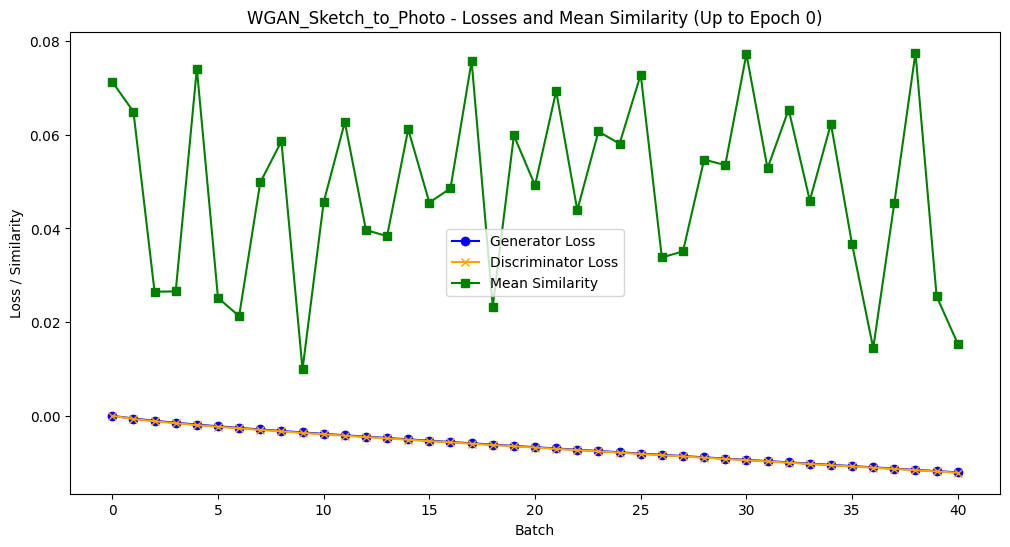

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step


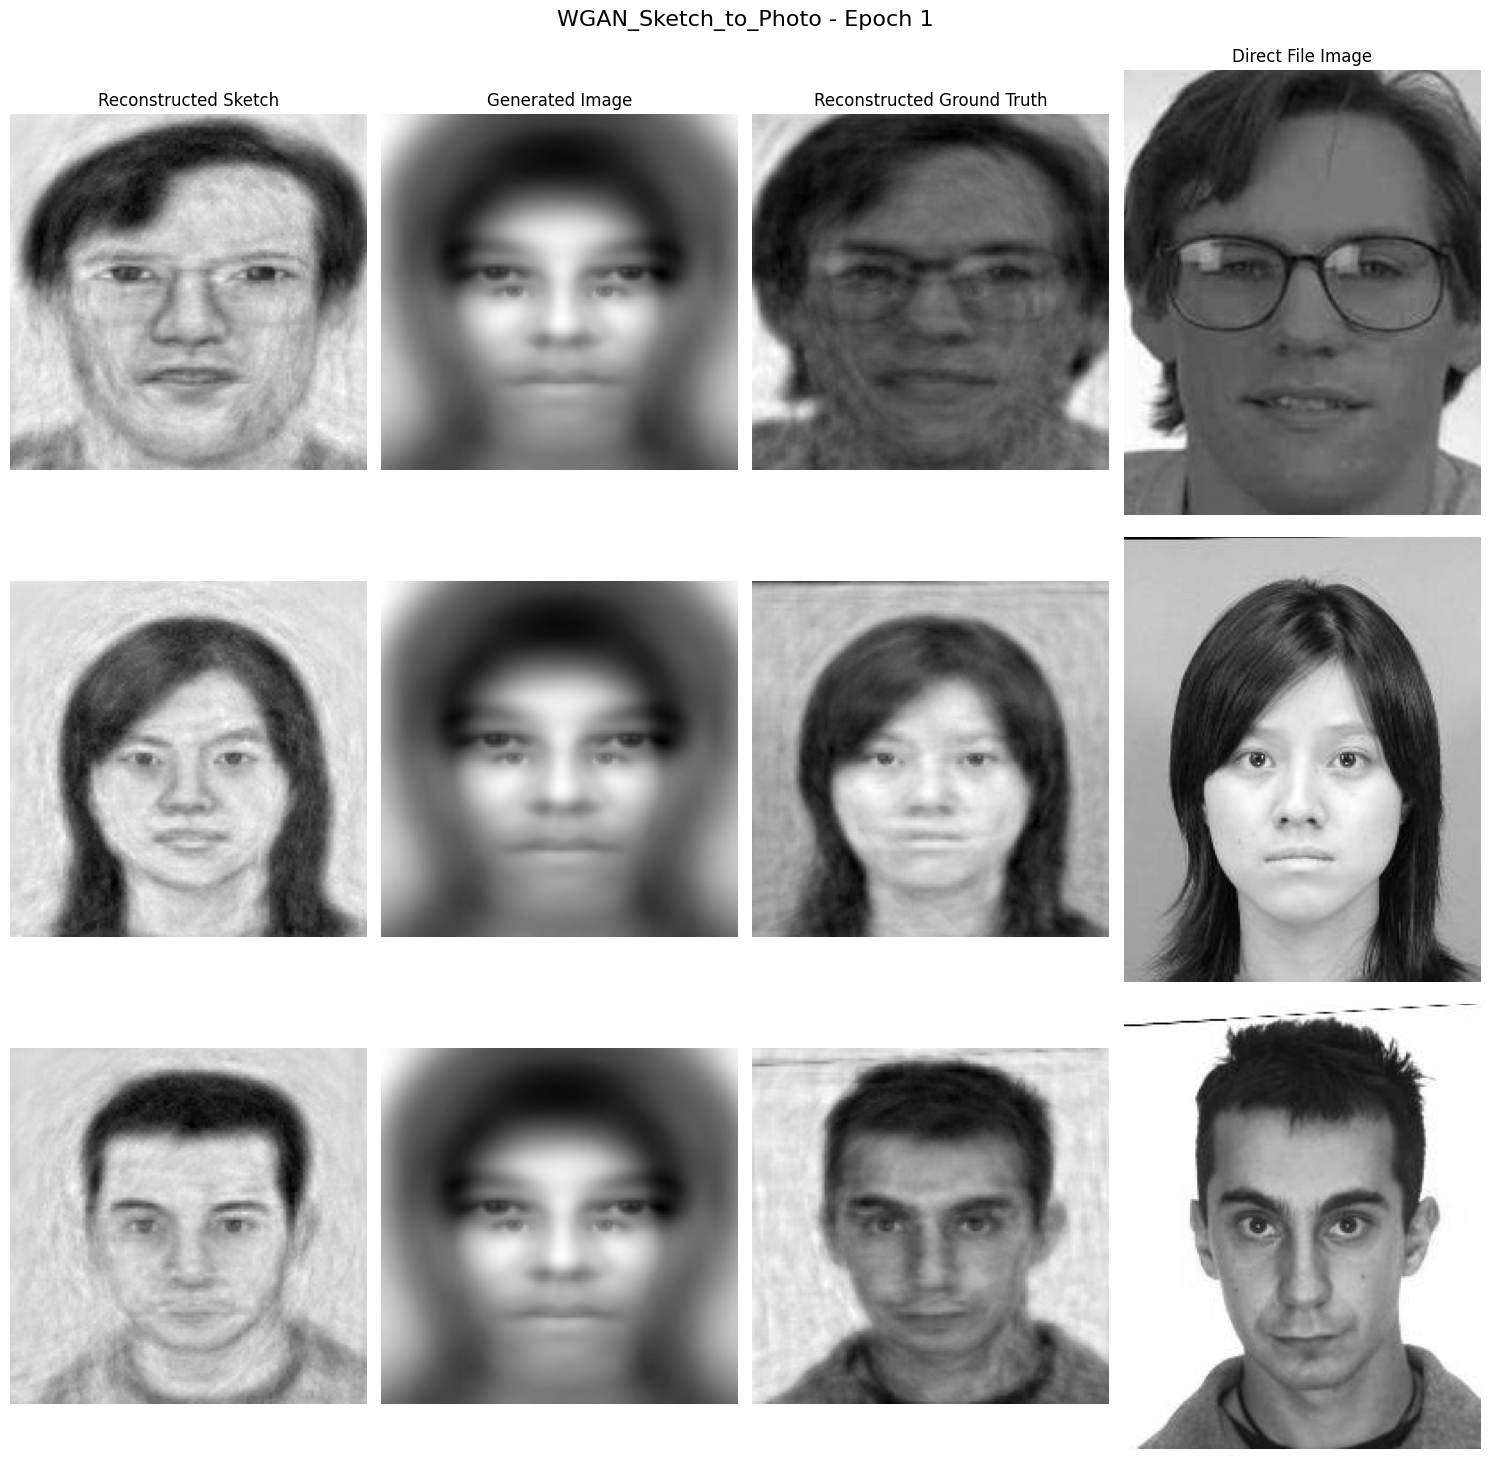

Training completed for model: WGAN_Sketch_to_Photo


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.optimizers import RMSprop, Adam
import numpy as np
import cv2
import os
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1
from scipy.spatial.distance import cosine
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import pickle

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define paths to the sketch and photo directories
sketch_folder = '/content/combined/sketches'
photo_folder = '/content/combined/photos'

# Define the target size for resizing images (e.g., 128x128)
target_size = (128, 128)

def load_and_preprocess_images(image_folder, target_size):
    """
    Load images from a folder, convert them to grayscale, resize, and flatten.

    Parameters:
    - image_folder: Path to the folder containing images.
    - target_size: Tuple specifying the desired image size.

    Returns:
    - images: Numpy array of flattened images.
    - filenames: List of image filenames.
    """
    images = []
    filenames = []
    for filename in os.listdir(image_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(image_folder, filename)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                # Resize the image to the target size
                resized_img = cv2.resize(img, target_size)
                # Flatten the resized image
                images.append(resized_img.flatten())
                filenames.append(filename)
    return np.array(images), filenames

# Load and preprocess sketches and photos
sketch_images, sketch_filenames = load_and_preprocess_images(sketch_folder, target_size)
photo_images, photo_filenames = load_and_preprocess_images(photo_folder, target_size)

# Apply PCA for dimensionality reduction
n_components = 400  # Adjust based on the desired level of reconstruction
sketch_pca = PCA(n_components=n_components)
reduced_sketch_vectors = sketch_pca.fit_transform(sketch_images)

photo_pca = PCA(n_components=n_components)
reduced_photo_vectors = photo_pca.fit_transform(photo_images)

# Parameters (adjusted for PCA reduction)
input_dim = reduced_sketch_vectors.shape[1]  # Reduced dimension for sketch features
output_dim = reduced_photo_vectors.shape[1]  # PCA components for photo features

def plot_metrics(generator_losses=None, discriminator_losses=None, mean_similarities=None,
                 batch_count=0, epoch=0, model_name='', target_dir=''):
    """
    Update the loss and similarity values, and generate a plot that accumulates over batches.
    A vertical line will separate the epochs for better distinction.

    Parameters:
    - generator_losses: List of generator losses up to the current batch (optional).
    - discriminator_losses: List of discriminator losses up to the current batch (optional).
    - mean_similarities: List of mean similarities up to the current batch (optional).
    - batch_count: The current batch count.
    - epoch: The current epoch.
    - model_name: Name of the model for saving the plot.
    - target_dir: Directory to save the plot.
    """

    # Check if there's any data to plot
    if generator_losses is None and discriminator_losses is None and mean_similarities is None:
        print("No data provided to plot.")
        return

    # Set up the plot
    plt.figure(figsize=(12, 6))

    # Plot Generator Loss if provided
    if generator_losses is not None:
        plt.plot(range(batch_count), generator_losses, 'o-', label='Generator Loss', color='blue')

    # Plot Discriminator Loss if provided
    if discriminator_losses is not None:
        plt.plot(range(batch_count), discriminator_losses, 'x-', label='Discriminator Loss', color='orange')

    # Plot Mean Similarity if provided
    if mean_similarities is not None:
        plt.plot(range(batch_count), mean_similarities, 's-', label='Mean Similarity', color='green')

    # Add title and labels
    plt.title(f'{model_name} - Losses and Mean Similarity (Up to Epoch {epoch})')
    plt.xlabel('Batch')
    plt.ylabel('Loss / Similarity')

    # Show legend
    plt.legend()

    # Add vertical lines to separate epochs
    for e in range(1, epoch + 1):
        plt.axvline(x=e * (batch_count // (epoch + 1)), color='red', linestyle='--', linewidth=1)

    # Ensure the target directory exists
    if target_dir and not os.path.exists(target_dir):
        os.makedirs(target_dir)

    # Save the plot
    plot_path = os.path.join(target_dir, f"metrics_epoch_{epoch}.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

    print(f"Plot saved at: {plot_path}")

# Wasserstein loss function
def wasserstein_loss(y_true, y_pred):
    """
    Compute the Wasserstein loss.

    Parameters:
    - y_true: True labels.
    - y_pred: Predicted labels.

    Returns:
    - Loss value.
    """
    return tf.reduce_mean(y_true * y_pred)

# Generator Model using U-Net architecture
def build_unet_generator(input_dim, output_dim):
    """
    Build the U-Net generator model.

    Parameters:
    - input_dim: Dimension of the input vector.
    - output_dim: Dimension of the output vector.

    Returns:
    - Keras Model representing the generator.
    """
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(512, activation=None)(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Reshape((16, 16, 2))(x)

    # Downsampling path
    conv1 = layers.Conv2D(64, kernel_size=3, padding='same')(x)
    conv1 = layers.LeakyReLU(alpha=0.2)(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(128, kernel_size=3, padding='same')(pool1)
    conv2 = layers.LeakyReLU(alpha=0.2)(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    # Bottleneck
    bottleneck = layers.Conv2D(256, kernel_size=3, padding='same')(pool2)
    bottleneck = layers.LeakyReLU(alpha=0.2)(bottleneck)
    bottleneck = layers.BatchNormalization()(bottleneck)

    # Upsampling path
    up2 = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same')(bottleneck)
    up2 = layers.concatenate([up2, conv2])
    up2 = layers.Conv2D(128, kernel_size=3, padding='same')(up2)
    up2 = layers.LeakyReLU(alpha=0.2)(up2)
    up2 = layers.BatchNormalization()(up2)

    up1 = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same')(up2)
    up1 = layers.concatenate([up1, conv1])
    up1 = layers.Conv2D(64, kernel_size=3, padding='same')(up1)
    up1 = layers.LeakyReLU(alpha=0.2)(up1)
    up1 = layers.BatchNormalization()(up1)

    outputs = layers.Conv2DTranspose(2, kernel_size=3, padding='same')(up1)
    outputs = layers.Flatten()(outputs)
    outputs = layers.Dense(output_dim, activation='tanh')(outputs)

    return Model(inputs, outputs)

# Discriminator Model
def build_wgan_discriminator(input_dim):
    """
    Build the Wasserstein GAN discriminator model.

    Parameters:
    - input_dim: Dimension of the input vector.

    Returns:
    - Keras Sequential model representing the discriminator.
    """
    model = Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(256, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(128, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(1, activation=None)  # No activation for WGAN
    ])
    return model

# Create the models
generator = build_unet_generator(input_dim, output_dim)
discriminator = build_wgan_discriminator(output_dim)

# Optimizer for the discriminator (RMSprop)
discriminator_opt = RMSprop(learning_rate=5e-5)

# Compile Discriminator with WGAN loss
discriminator.compile(loss=wasserstein_loss, optimizer=discriminator_opt)

# Build GAN Model
discriminator.trainable = False
gan_input = layers.Input(shape=(input_dim,))
generated_features = generator(gan_input)
gan_output = discriminator(generated_features)

gan = Model(gan_input, gan_output)

# Optimizer for the GAN model (Adam)
generator_opt = Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)

# Compile GAN model
gan.compile(loss=wasserstein_loss, optimizer=generator_opt)

# Initialize MTCNN and Resnet for face detection and embeddings
device = 'cuda' if torch.cuda.is_available() else 'cpu'
mtcnn = MTCNN(keep_all=True, device=device)
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

def get_face_embedding(image):
    """
    Extract face embedding from an image using MTCNN and ResNet.

    Parameters:
    - image: PIL Image object.

    Returns:
    - Numpy array representing the face embedding, or None if no face is detected.
    """
    # Convert the grayscale image to RGB by duplicating the single channel
    if image.mode != 'RGB':
        image = image.convert('RGB')

    # Detect faces in the image using MTCNN
    face_tensor = mtcnn(image)

    if face_tensor is None or face_tensor.shape[0] == 0:
        return None  # No face detected

    # Generate face embeddings using ResNet
    with torch.no_grad():
        embeddings = resnet(face_tensor.to(device))
    return embeddings[0].cpu().numpy() if embeddings is not None else None

def calculate_similarity(embedding1, embedding2):
    """
    Compute cosine similarity between two embeddings.

    Parameters:
    - embedding1: First embedding vector.
    - embedding2: Second embedding vector.

    Returns:
    - Cosine similarity score.
    """
    return 1 - cosine(embedding1, embedding2)

def train(d_model, g_model, gan_model, data, model_name, n_epochs=10000, n_batch=32, save_interval=1000):
    """
    Train the GAN models.

    Parameters:
    - d_model: Discriminator model.
    - g_model: Generator model.
    - gan_model: Combined GAN model.
    - data: Tuple of (sketch_vectors, photo_vectors, photo_filenames).
    - model_name: Name of the model for saving.
    - n_epochs: Number of epochs to train.
    - n_batch: Batch size.
    - save_interval: Interval (in epochs) to save models.
    """
    # Unpack data
    sketch_vectors, photo_vectors, photo_filenames = data

    # Determine the number of batches per epoch
    n_batches = int(len(sketch_vectors) / n_batch)

    # Buffers for metrics
    all_g_losses = []
    all_d_losses = []
    all_similarities = []
    batch_count = 0

    # Ensure directories exist
    os.makedirs(f'Models/{model_name}/metrics', exist_ok=True)
    os.makedirs(f'Models/{model_name}/output_images', exist_ok=True)

    for epoch in range(n_epochs):
        print(f' ========== Epoch {epoch+1} ========== ')

        # Shuffle the data at the start of each epoch
        sketch_vectors, photo_vectors, photo_filenames = shuffle(sketch_vectors, photo_vectors, photo_filenames, random_state=epoch)

        for j in range(n_batches):
            batch_count += 1
            start = j * n_batch
            end = start + n_batch

            # Get the batch data
            batch_sketch = sketch_vectors[start:end]
            batch_photo = photo_vectors[start:end]
            batch_filenames = photo_filenames[start:end]

            # Generate fake features
            fake_features = g_model.predict(batch_sketch)

            # Real and fake labels
            real_labels = np.ones((n_batch, 1))
            fake_labels = np.zeros((n_batch, 1))

            # Train discriminator on real features
            d_model.trainable = True
            d_loss_real = d_model.train_on_batch(batch_photo, real_labels)
            if isinstance(d_loss_real, list):  # Handle multiple loss values
                d_loss_real = d_loss_real[0]

            # Train discriminator on fake features
            d_loss_fake = d_model.train_on_batch(fake_features, fake_labels)
            if isinstance(d_loss_fake, list):  # Handle multiple loss values
                d_loss_fake = d_loss_fake[0]

            # Compute average discriminator loss
            d_loss = 0.5 * (d_loss_real + d_loss_fake)

            # Set discriminator non-trainable for GAN training
            d_model.trainable = False

            # Train generator via GAN
            g_loss = gan_model.train_on_batch(batch_sketch, real_labels)  # Labels are real for generator
            if isinstance(g_loss, list):  # Handle multiple loss values
                g_loss = g_loss[0]

            # Reconstruct images from fake features
            reconstructed_images = photo_pca.inverse_transform(fake_features)
            reconstructed_images = reconstructed_images.reshape((-1, *target_size))

            # Calculate similarity for each image in the batch
            similarities = []
            for i in range(n_batch):
                generated_image = reconstructed_images[i].astype(np.uint8)
                generated_image_pil = Image.fromarray(generated_image)

                # Original image path
                original_image_path = os.path.join(photo_folder, batch_filenames[i])
                original_image = Image.open(original_image_path).convert('RGB')
                original_embedding = get_face_embedding(original_image)
                generated_embedding = get_face_embedding(generated_image_pil)

                if original_embedding is not None and generated_embedding is not None:
                    similarity = calculate_similarity(original_embedding, generated_embedding)
                    similarities.append(similarity)

            # Calculate mean similarity for the batch
            mean_similarity = np.mean(similarities) if similarities else 0.0

            # Print progress
            if batch_count % 10 == 0:
                print(f"Epoch {epoch+1}, Batch {j+1}/{n_batches} [D loss: {d_loss:.4f}] [G loss: {g_loss:.4f}] [Mean Similarity: {mean_similarity:.4f}]")

            # Append metrics for this batch
            all_g_losses.append(g_loss)
            all_d_losses.append(d_loss)
            all_similarities.append(mean_similarity)

        # Plot metrics and summarize performance every save_interval epochs
        if (epoch + 1) % save_interval == 0:
            plot_metrics(all_g_losses, all_d_losses, all_similarities, batch_count, epoch, model_name, target_dir=f'Models/{model_name}/metrics')

            # Use the new summarize_performance function
            summarize_performance(
                step=epoch,
                g_model=g_model,
                d_model=d_model,
                data=(sketch_vectors, photo_vectors, photo_filenames),
                model_name=model_name,
                target_dir=f'Models/{model_name}/output_images/',
                n_samples=3
            )

    print(f"Training completed for model: {model_name}")


def summarize_performance(step, g_model, d_model, data, model_name, target_dir='', n_samples=3):
    """
    Summarize the performance by generating sample outputs and saving models.

    Parameters:
    - step: Current epoch number.
    - g_model: Generator model.
    - d_model: Discriminator model.
    - data: Tuple of (sketch_vectors, photo_vectors, photo_filenames).
    - model_name: Name of the model for saving.
    - target_dir: Directory to save outputs.
    - n_samples: Number of samples to generate.
    """
    # Unpack data
    sketch_vectors, photo_vectors, photo_filenames = data

    # Select random samples
    idx = np.random.randint(0, len(sketch_vectors), n_samples)
    selected_sketches = sketch_vectors[idx]
    selected_real_photos = photo_vectors[idx]
    selected_filenames = [photo_filenames[i] for i in idx]

    # Generate fake features
    fake_features = g_model.predict(selected_sketches)

    # Reconstruct images from features
    reconstructed_images = photo_pca.inverse_transform(fake_features)

    # Reconstruct original sketches from sketch vectors (reverse transform)
    reconstructed_sketches = sketch_pca.inverse_transform(selected_sketches)

    # Reverse transform the real photo vectors
    reconstructed_real_photos = photo_pca.inverse_transform(selected_real_photos)

    # Plot the images
    plt.figure(figsize=(15, 5 * n_samples))

    for i in range(n_samples):
        # Reconstructed sketch
        plt.subplot(n_samples, 4, 1 + i * 4)
        plt.axis('off')
        sketch_image = reconstructed_sketches[i]
        if len(sketch_image.shape) == 1:
            sketch_size = int(np.sqrt(sketch_image.shape[0]))
            plt.imshow(sketch_image.reshape((sketch_size, sketch_size)), cmap='gray')
        else:
            plt.imshow(sketch_image, cmap='gray')
        if i == 0:
            plt.title('Reconstructed Sketch', fontsize=12)

        # Generated image from reconstructed array
        generated_image = reconstructed_images[i]
        plt.subplot(n_samples, 4, 2 + i * 4)
        plt.axis('off')
        if len(generated_image.shape) == 1:
            generated_size = int(np.sqrt(generated_image.shape[0]))
            plt.imshow(generated_image.reshape((generated_size, generated_size)), cmap='gray')
        else:
            plt.imshow(generated_image, cmap='gray')  # If already 2D
        if i == 0:
            plt.title('Generated Image', fontsize=12)

        # Reconstructed real image (ground truth)
        plt.subplot(n_samples, 4, 3 + i * 4)
        plt.axis('off')
        real_image = reconstructed_real_photos[i]
        if len(real_image.shape) == 1:
            real_size = int(np.sqrt(real_image.shape[0]))
            plt.imshow(real_image.reshape((real_size, real_size)), cmap='gray')
        else:
            plt.imshow(real_image, cmap='gray')
        if i == 0:
            plt.title('Reconstructed Ground Truth', fontsize=12)

        # Direct image from file
        original_image_path = os.path.join(photo_folder, selected_filenames[i])
        original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
        plt.subplot(n_samples, 4, 4 + i * 4)
        plt.axis('off')
        if original_image is not None:
            plt.imshow(original_image, cmap='gray')
        else:
            plt.imshow(np.zeros_like(real_image), cmap='gray')  # Show a blank image if loading fails
        if i == 0:
            plt.title('Direct File Image', fontsize=12)

    plt.suptitle(f'{model_name} - Epoch {step+1}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)

    # Show the plot before saving
    plt.show()

    # Save the plot
    if target_dir:
        os.makedirs(target_dir, exist_ok=True)
        filename = f'{model_name}_summary_epoch_{step+1}.png'
        plt.savefig(os.path.join(target_dir, filename), dpi=300)
    plt.close()

    # Save the models
    if target_dir:
        g_model.save(os.path.join(target_dir, f'generator_epoch_{step+1}.h5'))
        d_model.save(os.path.join(target_dir, f'discriminator_epoch_{step+1}.h5'))


# Prepare data tuple
data = (reduced_sketch_vectors, reduced_photo_vectors, photo_filenames)

# Define model name
model_name = 'WGAN_Sketch_to_Photo Final'

# Start training
train(
    d_model=discriminator,
    g_model=generator,
    gan_model=gan,
    data=data,
    model_name=model_name,
    n_epochs=1,      # Adjust the number of epochs as needed
    n_batch=64,          # Adjust the batch size as needed
    save_interval=1   # Adjust the save interval as needed
)

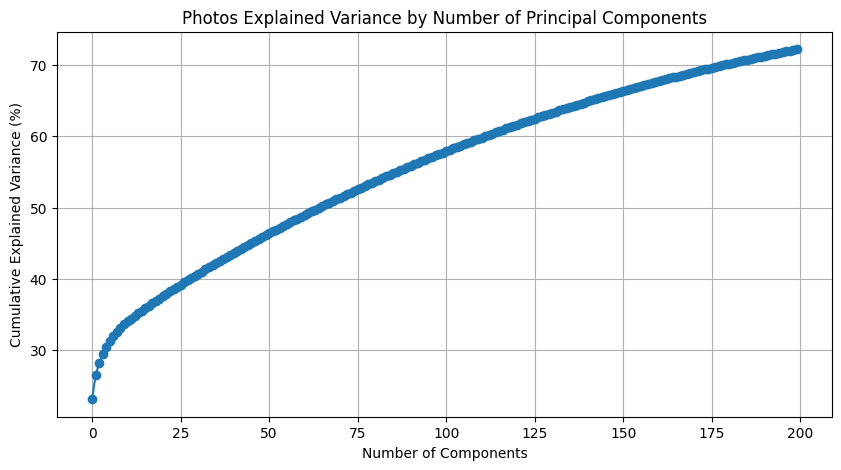

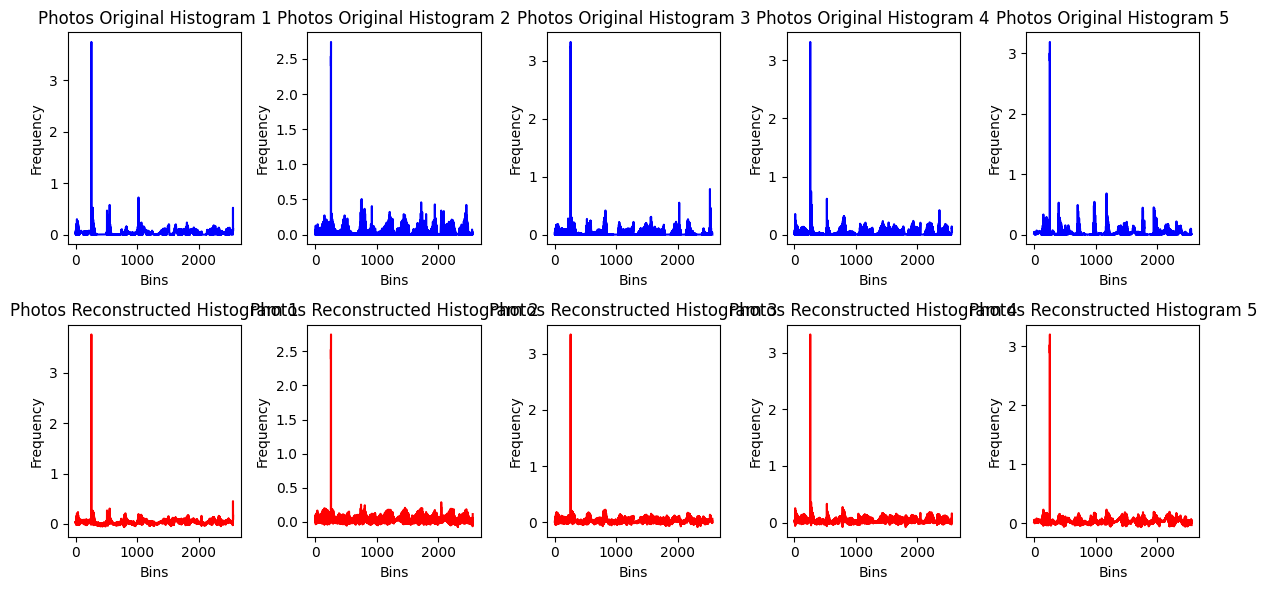

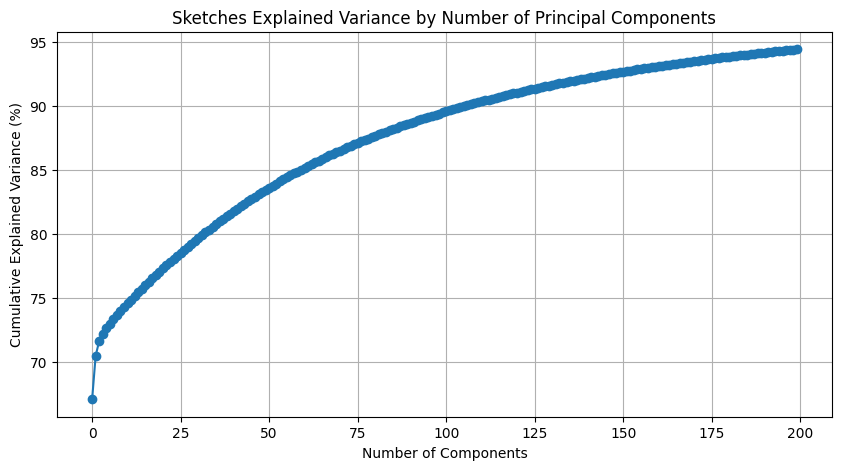

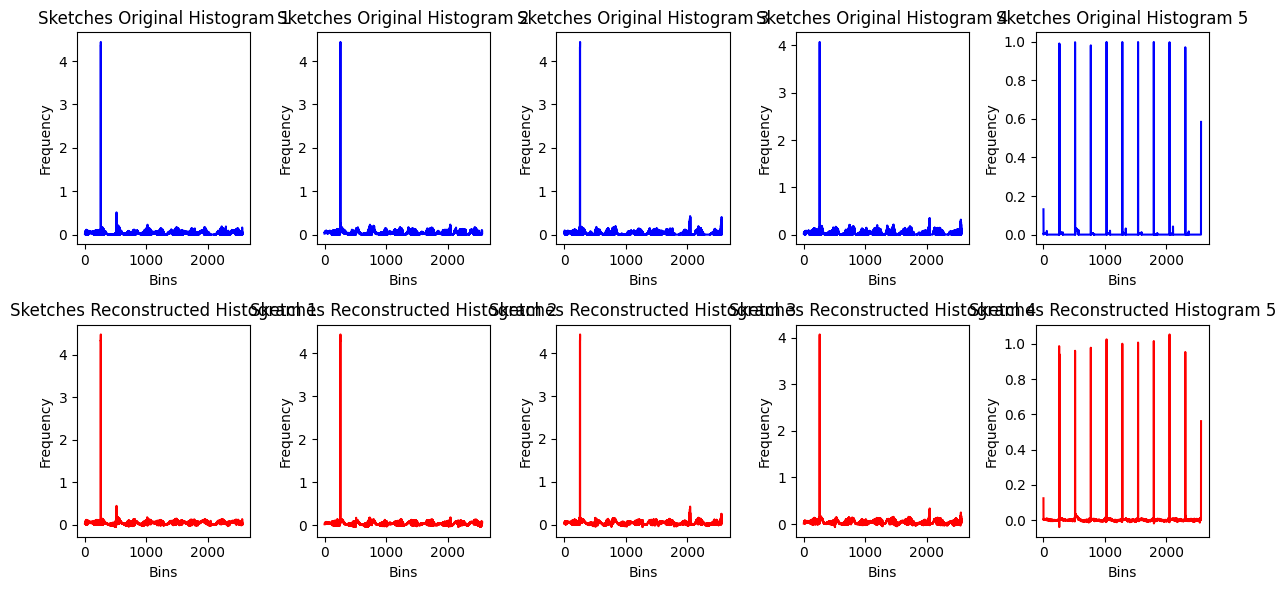

In [ ]:
import cv2
import numpy as np
import os
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Function to extract detailed features including global, regional, and local histograms
def extract_features(image_folder):
    all_feature_vectors = []
    filenames = []

    for filename in os.listdir(image_folder):
        if filename.endswith('.png') or filename.endswith('.jpg'):
            face_image = cv2.imread(os.path.join(image_folder, filename), cv2.IMREAD_GRAYSCALE)
            if face_image is None:
                continue

            # Histogram Equalization
            equalized_image = cv2.equalizeHist(face_image)

            # Compute the Global Histogram
            global_hist = cv2.calcHist([equalized_image], [0], None, [256], [0, 256])
            global_hist = cv2.normalize(global_hist, global_hist).flatten()

            # Extract Features from Specific Histogram Regions
            low_region_hist = np.sum(global_hist[:85])  # Low intensity range
            mid_region_hist = np.sum(global_hist[85:170])  # Mid intensity range
            high_region_hist = np.sum(global_hist[170:])  # High intensity range

            feature_vector = np.array([low_region_hist, mid_region_hist, high_region_hist])

            # Local Histogram Analysis (3x3 grid)
            height, width = equalized_image.shape
            grid_size = (3, 3)
            region_height = height // grid_size[0]
            region_width = width // grid_size[1]

            local_histograms = []

            for i in range(grid_size[0]):
                for j in range(grid_size[1]):
                    roi = equalized_image[i * region_height:(i + 1) * region_height, j * region_width:(j + 1) * region_width]
                    local_hist = cv2.calcHist([roi], [0], None, [256], [0, 256])
                    local_hist = cv2.normalize(local_hist, local_hist).flatten()
                    local_histograms.append(local_hist)

            # Combine Global and Local Features
            combined_feature_vector = np.hstack([global_hist, feature_vector, *local_histograms])

            all_feature_vectors.append(combined_feature_vector)
            filenames.append(filename)

    # Convert list to numpy array
    all_feature_vectors = np.array(all_feature_vectors)

    return all_feature_vectors, filenames

# Function to apply PCA, reconstruct features, and display results
def apply_pca_and_display(features, n_components, title_prefix):
    # Apply PCA for dimensionality reduction
    pca = PCA(n_components=n_components)
    reduced_features = pca.fit_transform(features)

    # Reconstruct the features
    reconstructed_features = pca.inverse_transform(reduced_features)

    # Display the explained variance ratio
    plt.figure(figsize=(10, 5))
    plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, marker='o')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance (%)')
    plt.title(f'{title_prefix} Explained Variance by Number of Principal Components')
    plt.grid(True)
    plt.show()

    # Display a few histograms (original vs reconstructed)
    num_images = min(5, len(features))  # Display up to 5 histograms
    indices_to_display = list(range(num_images))

    plt.figure(figsize=(12, 6))
    for i in indices_to_display:
        # Display the original histogram
        plt.subplot(2, num_images, i + 1)
        plt.title(f'{title_prefix} Original Histogram {i + 1}')
        plt.plot(features[i], color='blue')
        plt.xlabel('Bins')
        plt.ylabel('Frequency')

        # Display the reconstructed histogram
        plt.subplot(2, num_images, num_images + i + 1)
        plt.title(f'{title_prefix} Reconstructed Histogram {i + 1}')
        plt.plot(reconstructed_features[i], color='red')
        plt.xlabel('Bins')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# Define the number of PCA components
n_components = 200  # Adjust based on the desired level of reconstruction

# Define the paths to the image datasets
photo_folder = '/content/combined/photos'  # Update with your path
sketch_folder = '/content/combined/sketches'  # Update with your path

# Extract features from photos
photo_features, photo_filenames = extract_features(photo_folder)
apply_pca_and_display(photo_features, n_components, 'Photos')

# Extract features from sketches
sketch_features, sketch_filenames = extract_features(sketch_folder)
apply_pca_and_display(sketch_features, n_components, 'Sketches')


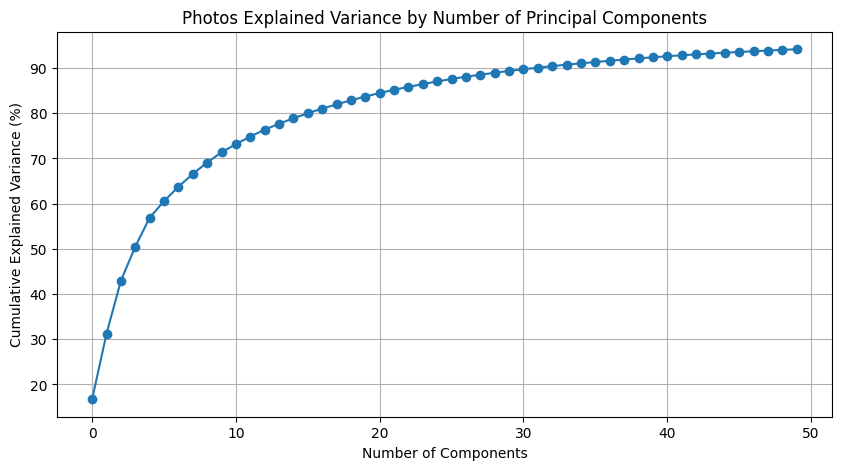

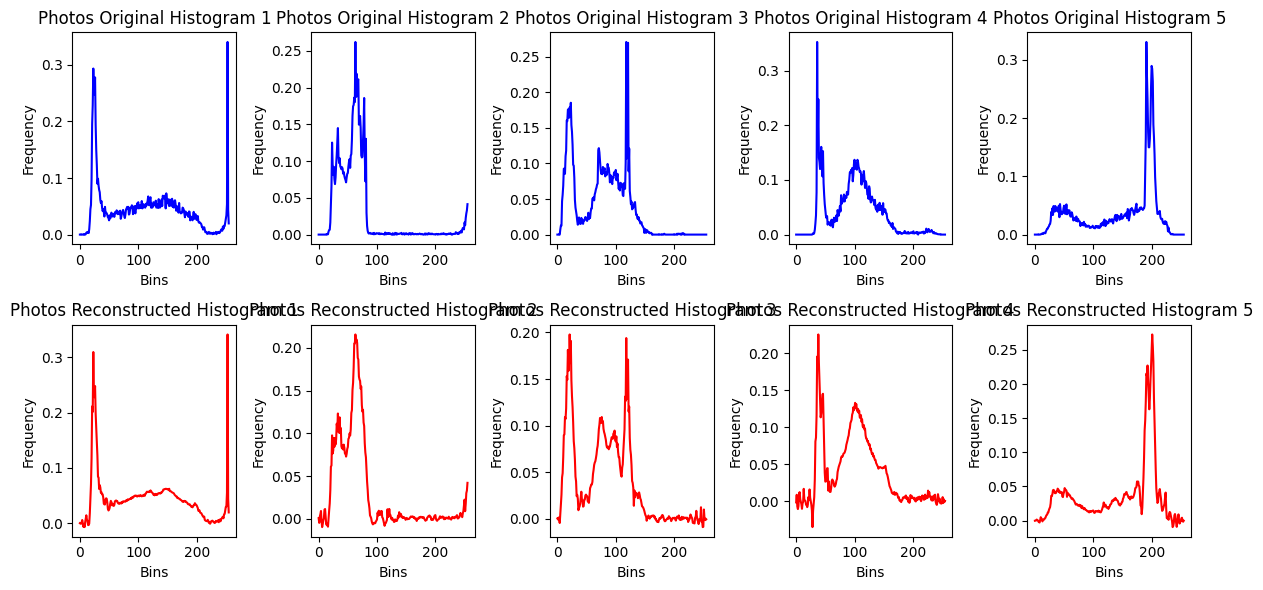

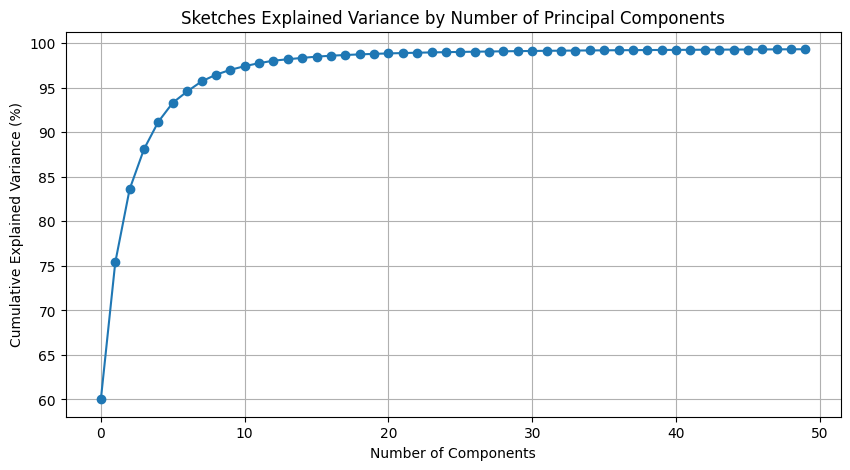

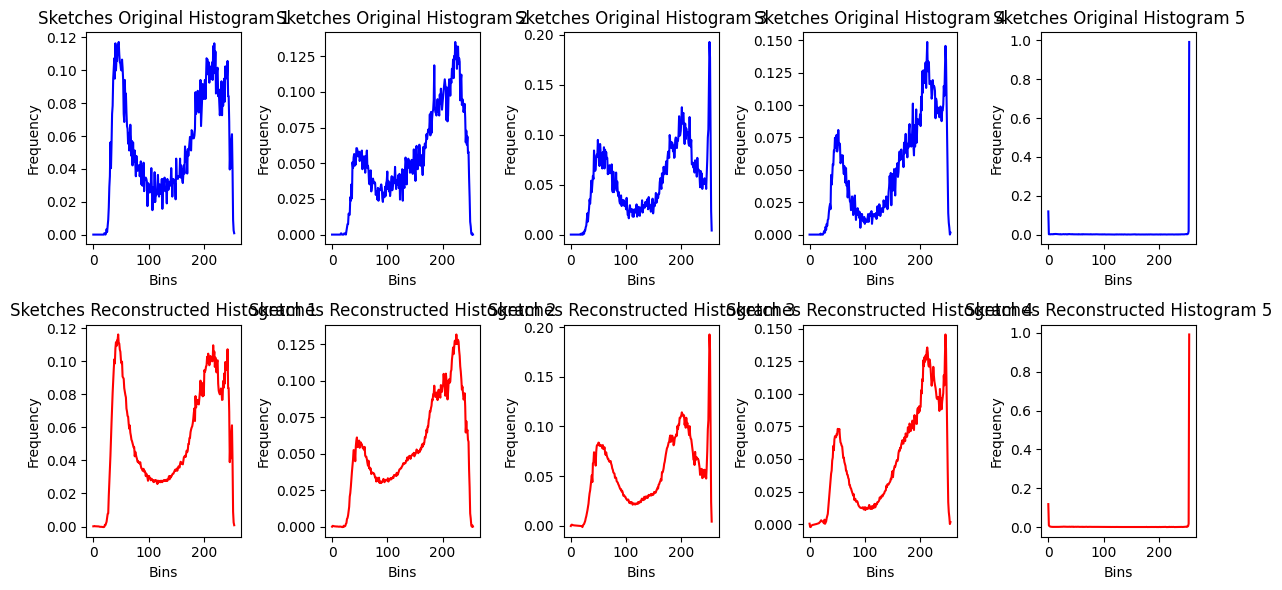

In [ ]:
import cv2
import numpy as np
import os
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Function to load images, resize, and extract histogram features
def load_and_extract_histograms(image_folder, target_size, hist_size=256):
    histograms = []
    filenames = []
    for filename in os.listdir(image_folder):
        if filename.endswith('.png') or filename.endswith('.jpg'):
            img = cv2.imread(os.path.join(image_folder, filename), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                # Resize the image to the target size
                resized_img = cv2.resize(img, target_size)
                # Calculate the histogram of the resized image
                hist = cv2.calcHist([resized_img], [0], None, [hist_size], [0, 256])
                # Normalize the histogram
                hist = cv2.normalize(hist, hist).flatten()
                histograms.append(hist)
                filenames.append(filename)
    return np.array(histograms), filenames

# Function to apply PCA, reconstruct features, and display results
def apply_pca_and_display(features, n_components, hist_size, title_prefix):
    # Apply PCA for dimensionality reduction
    pca = PCA(n_components=n_components)
    reduced_features = pca.fit_transform(features)

    # Reconstruct the features
    reconstructed_features = pca.inverse_transform(reduced_features)

    # Display the explained variance ratio
    plt.figure(figsize=(10, 5))
    plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, marker='o')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance (%)')
    plt.title(f'{title_prefix} Explained Variance by Number of Principal Components')
    plt.grid(True)
    plt.show()

    # Display a few histograms (original vs reconstructed)
    num_images = min(5, len(features))  # Display up to 5 histograms
    indices_to_display = list(range(num_images))

    plt.figure(figsize=(12, 6))
    for i in indices_to_display:
        # Display the original histogram
        plt.subplot(2, num_images, i + 1)
        plt.title(f'{title_prefix} Original Histogram {i + 1}')
        plt.plot(features[i], color='blue')
        plt.xlabel('Bins')
        plt.ylabel('Frequency')

        # Display the reconstructed histogram
        plt.subplot(2, num_images, num_images + i + 1)
        plt.title(f'{title_prefix} Reconstructed Histogram {i + 1}')
        plt.plot(reconstructed_features[i], color='red')
        plt.xlabel('Bins')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# Define the target size for resizing images (e.g., 128x128)
target_size = (128, 128)
n_components = 50  # Adjust based on the desired level of reconstruction

# Define the paths to the image datasets
photo_folder = '/content/combined/photos'  # Update with your path
sketch_folder = '/content/combined/sketches'  # Update with your path

# Process photos and extract histograms
photo_histograms, photo_filenames = load_and_extract_histograms(photo_folder, target_size)
apply_pca_and_display(photo_histograms, n_components, 256, 'Photos')

# Process sketches and extract histograms
sketch_histograms, sketch_filenames = load_and_extract_histograms(sketch_folder, target_size)
apply_pca_and_display(sketch_histograms, n_components, 256, 'Sketches')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: 0.6504] [G loss: 0.6760]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


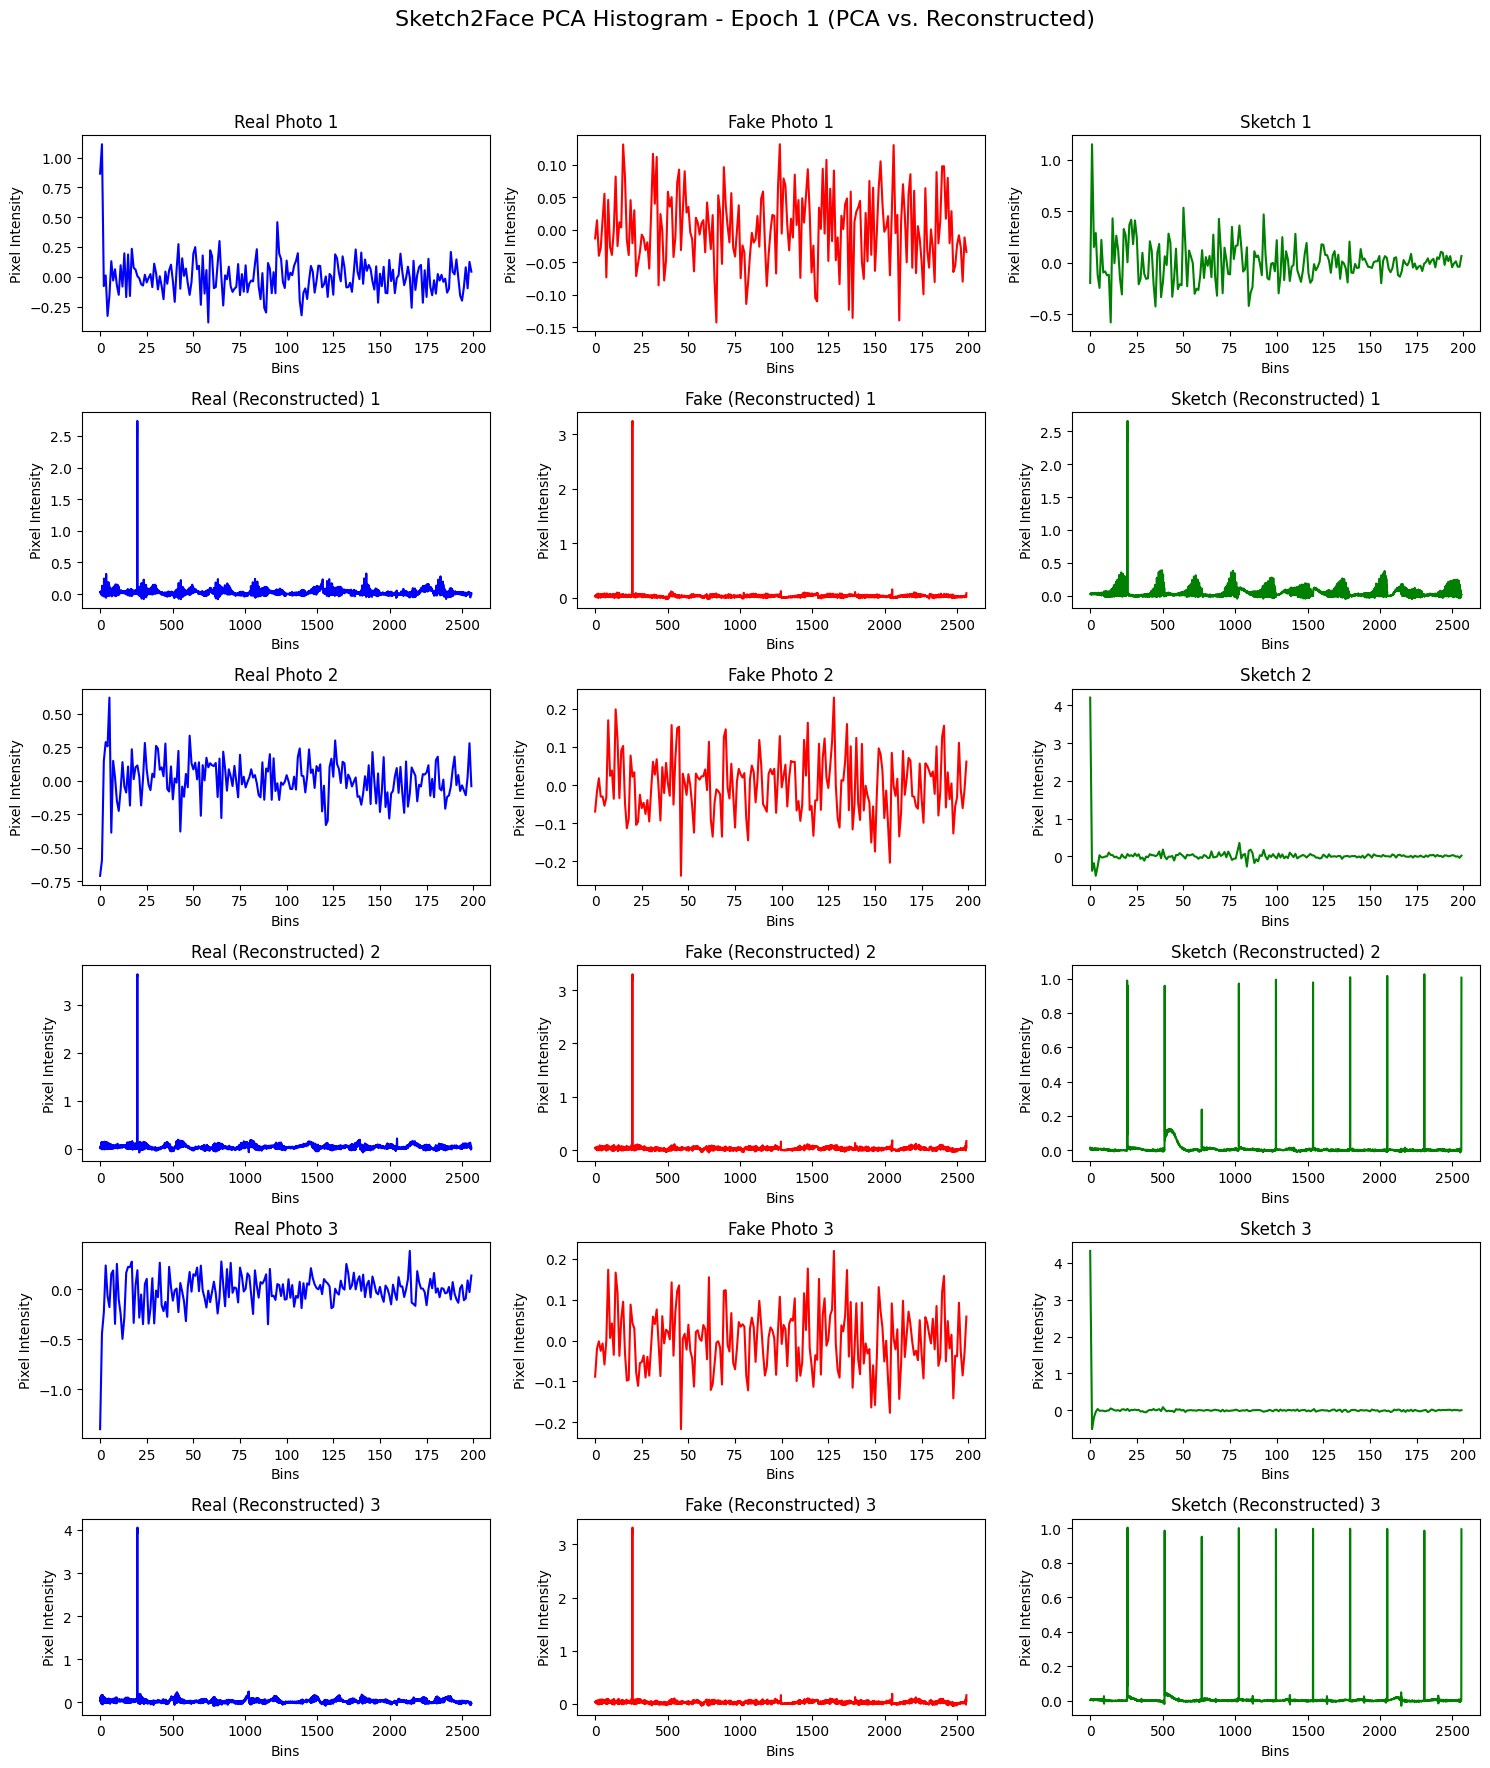

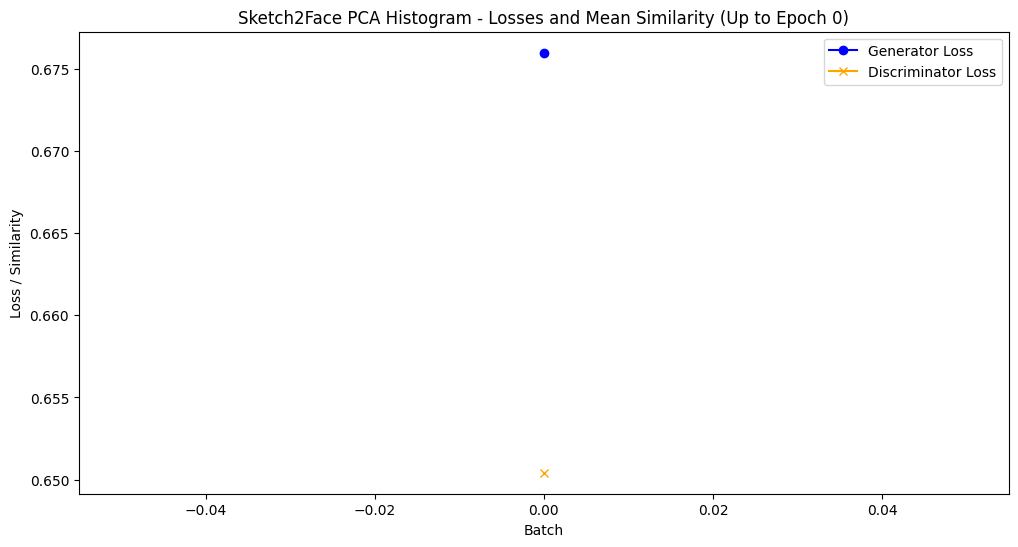

Plot saved at: Models/Sketch2Face PCA Histogram/metrics/metrics_epoch_0.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.optimizers import RMSprop, Adam
import numpy as np
import cv2
import os
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import numpy as np
import os

def summarize_performance_with_pca(step, g_model, d_model, data, model_name, pca_photo, pca_sketch, target_dir='', n_samples=3):
    sketch_vectors, photo_vectors, photo_filenames = data

    idx = np.random.randint(0, len(sketch_vectors), n_samples)
    selected_sketches = sketch_vectors[idx]
    selected_real_photos = photo_vectors[idx]
    selected_filenames = [photo_filenames[i] for i in idx]

    fake_features = g_model.predict(selected_sketches)

    plt.figure(figsize=(15, 6 * n_samples))

    for i in range(n_samples):
        real_photo = selected_real_photos[i].flatten()
        fake_photo = fake_features[i].flatten()
        sketch = selected_sketches[i].flatten()

        # Reconstruct the images using inverse PCA
        real_photo_reconstructed = pca_photo.inverse_transform([real_photo]).flatten()
        fake_photo_reconstructed = pca_photo.inverse_transform([fake_photo]).flatten()
        sketch_reconstructed = pca_sketch.inverse_transform([sketch]).flatten()

        # Plot original PCA images in the first row
        plt.subplot(n_samples * 2, 3, 1 + i * 6)
        plt.plot(real_photo, color='blue')
        plt.title(f'Real Photo {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        plt.subplot(n_samples * 2, 3, 2 + i * 6)
        plt.plot(fake_photo, color='red')
        plt.title(f'Fake Photo {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        plt.subplot(n_samples * 2, 3, 3 + i * 6)
        plt.plot(sketch, color='green')
        plt.title(f'Sketch {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        # Plot reconstructed images directly below the originals
        plt.subplot(n_samples * 2, 3, 4 + i * 6)
        plt.plot(real_photo_reconstructed, color='blue')
        plt.title(f'Real (Reconstructed) {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        plt.subplot(n_samples * 2, 3, 5 + i * 6)
        plt.plot(fake_photo_reconstructed, color='red')
        plt.title(f'Fake (Reconstructed) {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        plt.subplot(n_samples * 2, 3, 6 + i * 6)
        plt.plot(sketch_reconstructed, color='green')
        plt.title(f'Sketch (Reconstructed) {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

    plt.suptitle(f'{model_name} - Epoch {step + 1} (PCA vs. Reconstructed)', fontsize=16)

    # Adjust layout to add space between the suptitle and the plots
    plt.subplots_adjust(top=0.9)  # Adjust this value as needed

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the rectangle to ensure the title fits
    plt.show()

    # Save the plot and models (same as before)
    if target_dir:
        os.makedirs(target_dir, exist_ok=True)
        filename = f'{model_name}_pca_summary_epoch_{step + 1}.png'
        plt.savefig(os.path.join(target_dir, filename), dpi=300)
    plt.close()

    g_model.save(os.path.join(target_dir, f'generator_epoch_{step + 1}.h5'))
    d_model.save(os.path.join(target_dir, f'discriminator_epoch_{step + 1}.h5'))

def plot_metrics(generator_losses=None, discriminator_losses=None, mean_similarities=None,
                 batch_count=0, epoch=0, model_name='', target_dir=''):
    """
    Update the loss and similarity values, and generate a plot that accumulates over batches.
    A vertical line will separate the epochs for better distinction.

    Parameters:
    - generator_losses: List of generator losses up to the current batch (optional).
    - discriminator_losses: List of discriminator losses up to the current batch (optional).
    - mean_similarities: List of mean similarities up to the current batch (optional).
    - batch_count: The current batch count.
    - epoch: The current epoch.
    - model_name: Name of the model for saving the plot.
    - target_dir: Directory to save the plot.
    """

    # Check if there's any data to plot
    if generator_losses is None and discriminator_losses is None and mean_similarities is None:
        print("No data provided to plot.")
        return

    # Set up the plot
    plt.figure(figsize=(12, 6))

    # Plot Generator Loss if provided
    if generator_losses is not None:
        plt.plot(range(batch_count), generator_losses, 'o-', label='Generator Loss', color='blue')

    # Plot Discriminator Loss if provided
    if discriminator_losses is not None:
        plt.plot(range(batch_count), discriminator_losses, 'x-', label='Discriminator Loss', color='orange')

    # Plot Mean Similarity if provided
    if mean_similarities is not None:
        plt.plot(range(batch_count), mean_similarities, 's-', label='Mean Similarity', color='green')

    # Add title and labels
    plt.title(f'{model_name} - Losses and Mean Similarity (Up to Epoch {epoch})')
    plt.xlabel('Batch')
    plt.ylabel('Loss / Similarity')

    # Show legend
    plt.legend()

    # Add vertical lines to separate epochs
    for e in range(1, epoch + 1):
        plt.axvline(x=e * (batch_count // (epoch + 1)), color='red', linestyle='--', linewidth=1)

    # Ensure the target directory exists
    if target_dir and not os.path.exists(target_dir):
        os.makedirs(target_dir)

    # Save the plot
    plot_path = os.path.join(target_dir, f"metrics_epoch_{epoch}.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

    print(f"Plot saved at: {plot_path}")

# Generator Model
def build_generator(input_dim, output_dim):
    model = Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(output_dim, activation='tanh')
    ])
    return model

# Discriminator Model
def build_discriminator(input_dim):
    model = Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='leaky_relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='leaky_relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='leaky_relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Extract detailed features from images
def extract_features_with_pca(image_folder, n_components=200):
    all_feature_vectors = []
    filenames = []

    for filename in os.listdir(image_folder):
        if filename.endswith('.png') or filename.endswith('.jpg'):
            face_image = cv2.imread(os.path.join(image_folder, filename), cv2.IMREAD_GRAYSCALE)
            if face_image is None:
                continue

            # Histogram Equalization
            equalized_image = cv2.equalizeHist(face_image)

            # Compute the Global Histogram
            global_hist = cv2.calcHist([equalized_image], [0], None, [256], [0, 256])
            global_hist = cv2.normalize(global_hist, global_hist).flatten()

            # Extract Features from Specific Histogram Regions
            low_region_hist = np.sum(global_hist[:85])  # Low intensity range
            mid_region_hist = np.sum(global_hist[85:170])  # Mid intensity range
            high_region_hist = np.sum(global_hist[170:])  # High intensity range

            feature_vector = np.array([low_region_hist, mid_region_hist, high_region_hist])

            # Local Histogram Analysis (3x3 grid)
            height, width = equalized_image.shape
            grid_size = (3, 3)
            region_height = height // grid_size[0]
            region_width = width // grid_size[1]

            local_histograms = []

            for i in range(grid_size[0]):
                for j in range(grid_size[1]):
                    roi = equalized_image[i * region_height:(i + 1) * region_height, j * region_width:(j + 1) * region_width]
                    local_hist = cv2.calcHist([roi], [0], None, [256], [0, 256])
                    local_hist = cv2.normalize(local_hist, local_hist).flatten()
                    local_histograms.append(local_hist)

            # Combine Global and Local Features
            combined_feature_vector = np.hstack([global_hist, feature_vector, *local_histograms])

            all_feature_vectors.append(combined_feature_vector)
            filenames.append(filename)

    # Convert list to numpy array
    all_feature_vectors = np.array(all_feature_vectors)

    # Apply PCA transformation
    pca = PCA(n_components=n_components)
    transformed_features = pca.fit_transform(all_feature_vectors)

    return transformed_features, filenames, pca

# Define the paths to the image datasets
photo_folder = '/content/combined/photos'  # Update with your path
sketch_folder = '/content/combined/sketches'  # Update with your path

n_components=200

# Extract PCA-transformed features from photos and sketches
photo_features, photo_filenames, pca_photo = extract_features_with_pca(photo_folder,n_components)
sketch_features, sketch_filenames, pca_sketch = extract_features_with_pca(sketch_folder,n_components)

input_dim = sketch_features.shape[1]
output_dim = photo_features.shape[1]

# Create the models
generator = build_generator(input_dim, output_dim)  # Generator transforms sketch features to photo features
discriminator = build_discriminator(output_dim)     # Discriminator evaluates the realism of generated features

# Compile Discriminator
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5), metrics=['accuracy'])

# Build GAN Model
discriminator.trainable = False
gan_input = layers.Input(shape=(input_dim,))
generated_features = generator(gan_input)
gan_output = discriminator(generated_features)

gan = Model(gan_input, gan_output)
gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))

# Training loop
epochs = 10000  # Adjust the number of epochs
batch_size = 32  # Adjust the batch size
save_interval = 1000  # Adjust the save interval
model_name = 'Sketch2Face PCA Histogram'

# Initialize lists to keep track of losses and similarities
generator_losses = []
discriminator_losses = []
mean_similarities = []

for epoch in range(epochs):
    # Train Discriminator
    idx = np.random.randint(0, photo_features.shape[0], batch_size)
    real_features = photo_features[idx]
    fake_features = generator.predict(sketch_features[idx])

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_features, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_features, fake_labels)

    d_loss = 0.5 * (d_loss_real[0] + d_loss_fake[0])

    # Train Generator
    g_loss = gan.train_on_batch(sketch_features[idx], real_labels)

    # Store losses for plotting
    generator_losses.append(g_loss[0])
    discriminator_losses.append(d_loss)

    # Print progress
    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {d_loss:.4f}] [G loss: {g_loss[0]:.4f}]")

    # Save generator model and summarize performance at intervals
    if epoch % save_interval == 0:
        summarize_performance_with_pca(
            step=epoch,
            g_model=generator,
            d_model=discriminator,
            data=(sketch_features, photo_features, photo_filenames),
            model_name=model_name,
            pca_photo=pca_photo,
            pca_sketch=pca_sketch,
            target_dir=f'Models/{model_name}/output_images_pca/',
            n_samples=3
        )

    # Plot metrics at the end of each epoch
    if epoch % save_interval == 0:
        plot_metrics(
            generator_losses=generator_losses,
            discriminator_losses=discriminator_losses,
            batch_count=len(generator_losses),
            epoch=epoch,
            model_name=model_name,
            target_dir=f'Models/{model_name}/metrics/'
        )

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.optimizers import RMSprop, Adam
import numpy as np
import cv2
import os

import matplotlib.pyplot as plt

def summarize_performance(step, g_model, d_model, data, model_name, target_dir='', n_samples=3):
    """
    Summarize the performance by generating sample outputs and saving models.

    Parameters:
    - step: Current epoch number.
    - g_model: Generator model.
    - d_model: Discriminator model.
    - data: Tuple of (sketch_vectors, photo_vectors, photo_filenames).
    - model_name: Name of the model for saving.
    - target_dir: Directory to save outputs.
    - n_samples: Number of samples to generate.
    """
    # Unpack data
    sketch_vectors, photo_vectors, photo_filenames = data

    # Select random samples
    idx = np.random.randint(0, len(sketch_vectors), n_samples)
    selected_sketches = sketch_vectors[idx]
    selected_real_photos = photo_vectors[idx]
    selected_filenames = [photo_filenames[i] for i in idx]

    # Generate fake features
    fake_features = g_model.predict(selected_sketches)

    # Plot line plots instead of histograms
    plt.figure(figsize=(15, 5 * n_samples))

    for i in range(n_samples):
        # Flatten the images for line plotting
        real_photo = selected_real_photos[i].flatten()
        fake_photo = fake_features[i].flatten()
        sketch = selected_sketches[i].flatten()

        # Plot Real Photo line plot
        plt.subplot(n_samples, 3, 1 + i * 3)
        plt.plot(real_photo, color='blue')
        plt.title(f'Real Photo Line Plot {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        # Plot Fake Photo line plot
        plt.subplot(n_samples, 3, 2 + i * 3)
        plt.plot(fake_photo, color='red')
        plt.title(f'Fake Photo Line Plot {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        # Plot Sketch line plot
        plt.subplot(n_samples, 3, 3 + i * 3)
        plt.plot(sketch, color='green')
        plt.title(f'Sketch Line Plot {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

    plt.suptitle(f'{model_name} - Epoch {step + 1}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)

    # Show the plot before saving
    plt.show()

    # Save the plot
    if target_dir:
        os.makedirs(target_dir, exist_ok=True)
        filename = f'{model_name}_summary_epoch_{step + 1}.png'
        plt.savefig(os.path.join(target_dir, filename), dpi=300)
    plt.close()

    # Save the models
    if target_dir:
        g_model.save(os.path.join(target_dir, f'generator_epoch_{step + 1}.h5'))
        d_model.save(os.path.join(target_dir, f'discriminator_epoch_{step + 1}.h5'))

def plot_metrics(generator_losses=None, discriminator_losses=None, mean_similarities=None,
                 batch_count=0, epoch=0, model_name='', target_dir=''):
    """
    Update the loss and similarity values, and generate a plot that accumulates over batches.
    A vertical line will separate the epochs for better distinction.

    Parameters:
    - generator_losses: List of generator losses up to the current batch (optional).
    - discriminator_losses: List of discriminator losses up to the current batch (optional).
    - mean_similarities: List of mean similarities up to the current batch (optional).
    - batch_count: The current batch count.
    - epoch: The current epoch.
    - model_name: Name of the model for saving the plot.
    - target_dir: Directory to save the plot.
    """

    # Check if there's any data to plot
    if generator_losses is None and discriminator_losses is None and mean_similarities is None:
        print("No data provided to plot.")
        return

    # Set up the plot
    plt.figure(figsize=(12, 6))

    # Plot Generator Loss if provided
    if generator_losses is not None:
        plt.plot(range(batch_count), generator_losses, 'o-', label='Generator Loss', color='blue')

    # Plot Discriminator Loss if provided
    if discriminator_losses is not None:
        plt.plot(range(batch_count), discriminator_losses, 'x-', label='Discriminator Loss', color='orange')

    # Plot Mean Similarity if provided
    if mean_similarities is not None:
        plt.plot(range(batch_count), mean_similarities, 's-', label='Mean Similarity', color='green')

    # Add title and labels
    plt.title(f'{model_name} - Losses and Mean Similarity (Up to Epoch {epoch})')
    plt.xlabel('Batch')
    plt.ylabel('Loss / Similarity')

    # Show legend
    plt.legend()

    # Add vertical lines to separate epochs
    for e in range(1, epoch + 1):
        plt.axvline(x=e * (batch_count // (epoch + 1)), color='red', linestyle='--', linewidth=1)

    # Ensure the target directory exists
    if target_dir and not os.path.exists(target_dir):
        os.makedirs(target_dir)

    # Save the plot
    plot_path = os.path.join(target_dir, f"metrics_epoch_{epoch}.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

    print(f"Plot saved at: {plot_path}")

# Wasserstein loss function
def wasserstein_loss(y_true, y_pred):
    return tf.reduce_mean(y_true * y_pred)

# Generator Model using U-Net architecture
def build_unet_generator(input_dim, output_dim):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(512, activation=None)(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Reshape((16, 16, 2))(x)

    # Downsampling path
    conv1 = layers.Conv2D(64, kernel_size=3, padding='same')(x)
    conv1 = layers.LeakyReLU(alpha=0.2)(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(128, kernel_size=3, padding='same')(pool1)
    conv2 = layers.LeakyReLU(alpha=0.2)(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    # Bottleneck
    bottleneck = layers.Conv2D(256, kernel_size=3, padding='same')(pool2)
    bottleneck = layers.LeakyReLU(alpha=0.2)(bottleneck)
    bottleneck = layers.BatchNormalization()(bottleneck)

    # Upsampling path
    up2 = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same')(bottleneck)
    up2 = layers.concatenate([up2, conv2])
    up2 = layers.Conv2D(128, kernel_size=3, padding='same')(up2)
    up2 = layers.LeakyReLU(alpha=0.2)(up2)
    up2 = layers.BatchNormalization()(up2)

    up1 = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same')(up2)
    up1 = layers.concatenate([up1, conv1])
    up1 = layers.Conv2D(64, kernel_size=3, padding='same')(up1)
    up1 = layers.LeakyReLU(alpha=0.2)(up1)
    up1 = layers.BatchNormalization()(up1)

    outputs = layers.Conv2DTranspose(2, kernel_size=3, padding='same')(up1)
    outputs = layers.Flatten()(outputs)
    outputs = layers.Dense(output_dim, activation='tanh')(outputs)

    return Model(inputs, outputs)

# Discriminator Model
def build_wgan_discriminator(input_dim):
    model = Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(256, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(128, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(1, activation=None)  # No activation for WGAN
    ])
    return model

# Extract detailed features from images
def extract_features(image_folder):
    all_feature_vectors = []
    filenames = []

    for filename in os.listdir(image_folder):
        if filename.endswith('.png') or filename.endswith('.jpg'):
            face_image = cv2.imread(os.path.join(image_folder, filename), cv2.IMREAD_GRAYSCALE)
            if face_image is None:
                continue

            # Histogram Equalization
            equalized_image = cv2.equalizeHist(face_image)

            # Compute the Global Histogram
            global_hist = cv2.calcHist([equalized_image], [0], None, [256], [0, 256])
            global_hist = cv2.normalize(global_hist, global_hist).flatten()

            # Extract Features from Specific Histogram Regions
            low_region_hist = np.sum(global_hist[:85])  # Low intensity range
            mid_region_hist = np.sum(global_hist[85:170])  # Mid intensity range
            high_region_hist = np.sum(global_hist[170:])  # High intensity range

            feature_vector = np.array([low_region_hist, mid_region_hist, high_region_hist])

            # Local Histogram Analysis (3x3 grid)
            height, width = equalized_image.shape
            grid_size = (3, 3)
            region_height = height // grid_size[0]
            region_width = width // grid_size[1]

            local_histograms = []

            for i in range(grid_size[0]):
                for j in range(grid_size[1]):
                    roi = equalized_image[i * region_height:(i + 1) * region_height, j * region_width:(j + 1) * region_width]
                    local_hist = cv2.calcHist([roi], [0], None, [256], [0, 256])
                    local_hist = cv2.normalize(local_hist, local_hist).flatten()
                    local_histograms.append(local_hist)

            # Combine Global and Local Features
            combined_feature_vector = np.hstack([global_hist, feature_vector, *local_histograms])

            all_feature_vectors.append(combined_feature_vector)
            filenames.append(filename)

    # Convert list to numpy array
    all_feature_vectors = np.array(all_feature_vectors)

    return all_feature_vectors, filenames

# Define the paths to the image datasets
photo_folder = '/content/combined/photos'  # Update with your path
sketch_folder = '/content/combined/sketches'  # Update with your path

# Extract features from photos
photo_features, photo_filenames = extract_features(photo_folder)
# Extract features from sketches
sketch_features, sketch_filenames = extract_features(sketch_folder)

input_dim = sketch_features.shape[1]
output_dim = photo_features.shape[1]

# Create the models
generator = build_unet_generator(input_dim, output_dim)
discriminator = build_wgan_discriminator(output_dim)

# Optimizer for the discriminator (RMSprop)
discriminator_opt = RMSprop(learning_rate=5e-5)

# Compile Discriminator with WGAN loss
discriminator.compile(loss=wasserstein_loss, optimizer=discriminator_opt)

# Build GAN Model
discriminator.trainable = False
gan_input = layers.Input(shape=(input_dim,))
generated_features = generator(gan_input)
gan_output = discriminator(generated_features)

gan = Model(gan_input, gan_output)

# Optimizer for the GAN model (Adam)
generator_opt = Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)

# Compile GAN model
gan.compile(loss=wasserstein_loss, optimizer=generator_opt)

# Training loop
epochs = 10000  # Adjust the number of epochs
batch_size = 32  # Adjust the batch size
save_interval = 1  # Adjust the save interval
model_name = 'Sketch2Face WGAN Histogram'

# Initialize lists to keep track of losses and similarities
generator_losses = []
discriminator_losses = []
mean_similarities = []

for epoch in range(epochs):
    # Train Discriminator
    idx = np.random.randint(0, photo_features.shape[0], batch_size)
    real_features = photo_features[idx]
    fake_features = generator.predict(sketch_features[idx])

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_features, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_features, fake_labels)

    d_loss = 0.5 * (d_loss_real + d_loss_fake)

    # Train Generator
    g_loss,_ = gan.train_on_batch(sketch_features[idx], real_labels)

    # Store losses for plotting
    generator_losses.append(g_loss)
    discriminator_losses.append(d_loss)

    # Print progress
    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {d_loss:.4f}] [G loss: {g_loss:.4f}]")

    # Save generator model and summarize performance at intervals
    if epoch % save_interval == 0:
        summarize_performance(
            step=epoch,
            g_model=generator,
            d_model=discriminator,
            data=(sketch_features, photo_features, photo_filenames),
            model_name=model_name,
            target_dir=f'Models/{model_name}/output_images/',
            n_samples=3
        )

    # Plot metrics at the end of each epoch
    if epoch % save_interval == 0:
        plot_metrics(
            generator_losses=generator_losses,
            discriminator_losses=discriminator_losses,
            batch_count=len(generator_losses),
            epoch=epoch,
            model_name=model_name,
            target_dir=f'Models/{model_name}/metrics/'
        )

/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/backend/tensorflow/trainer.py:75: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: -0.0642] [G loss: -0.0428]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step


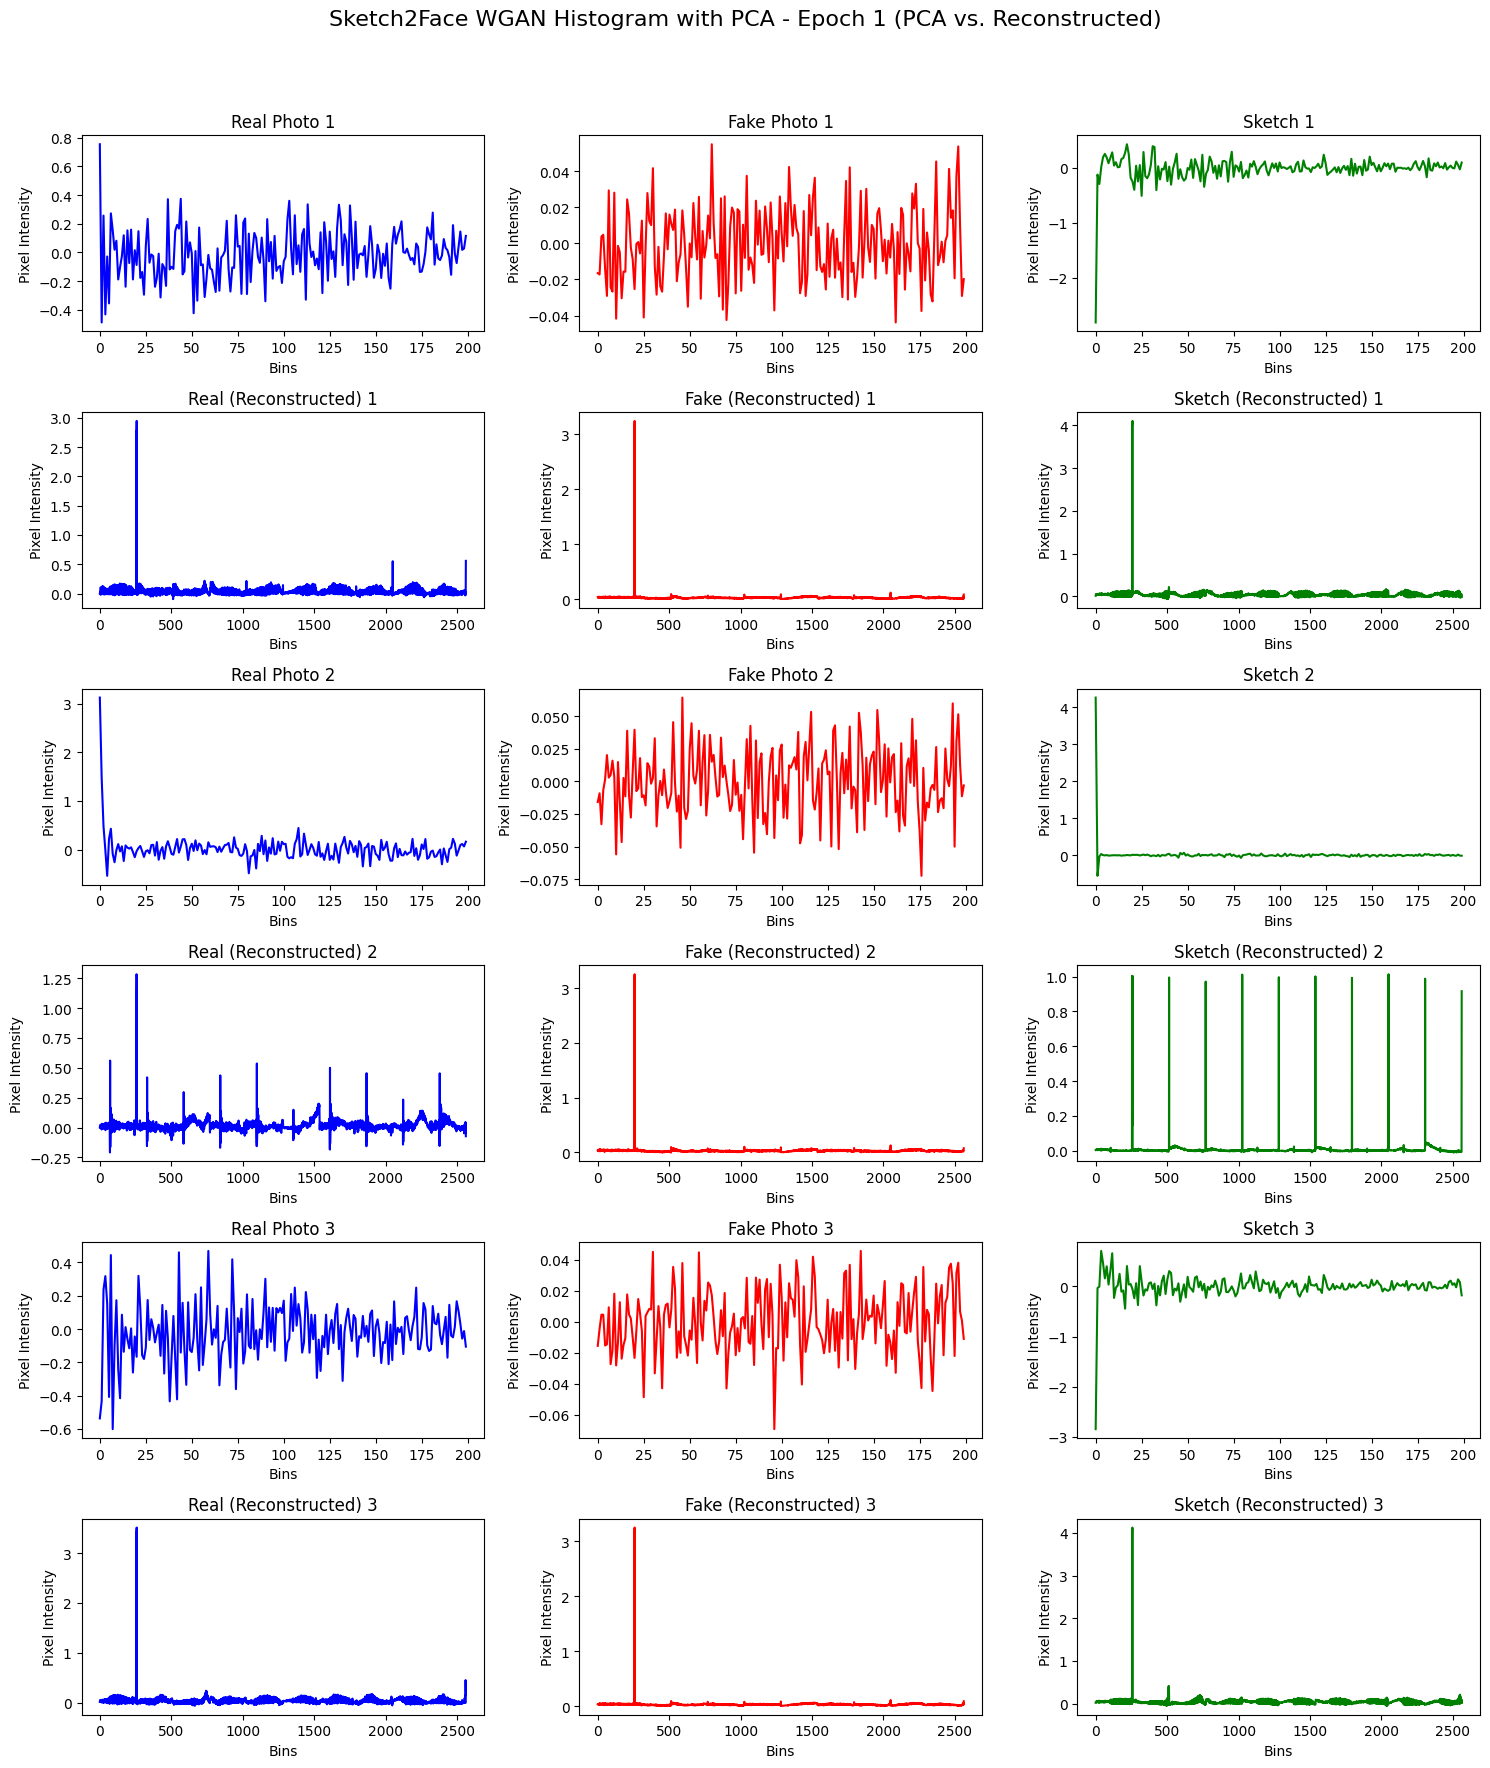

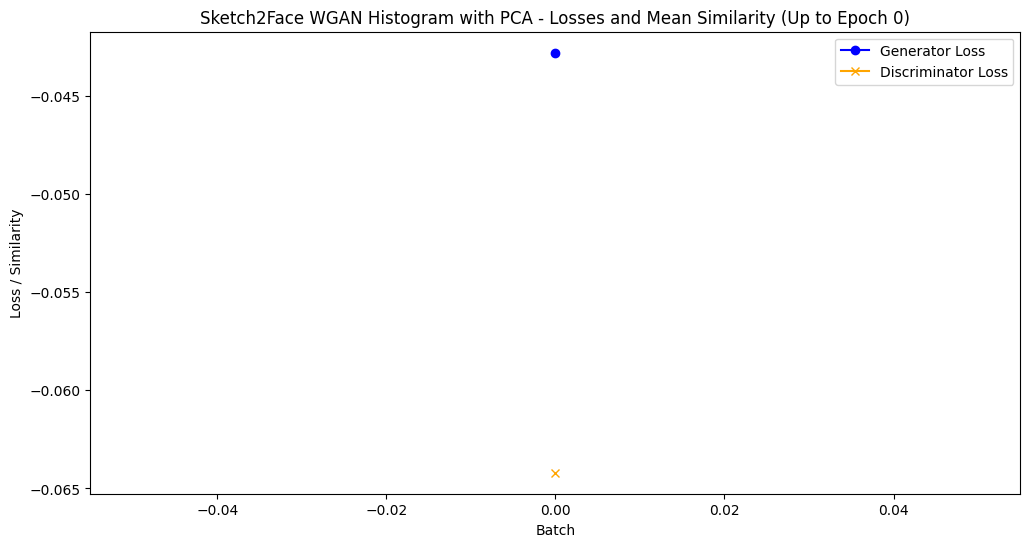

Plot saved at: Models/Sketch2Face WGAN Histogram with PCA/metrics/metrics_epoch_0.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


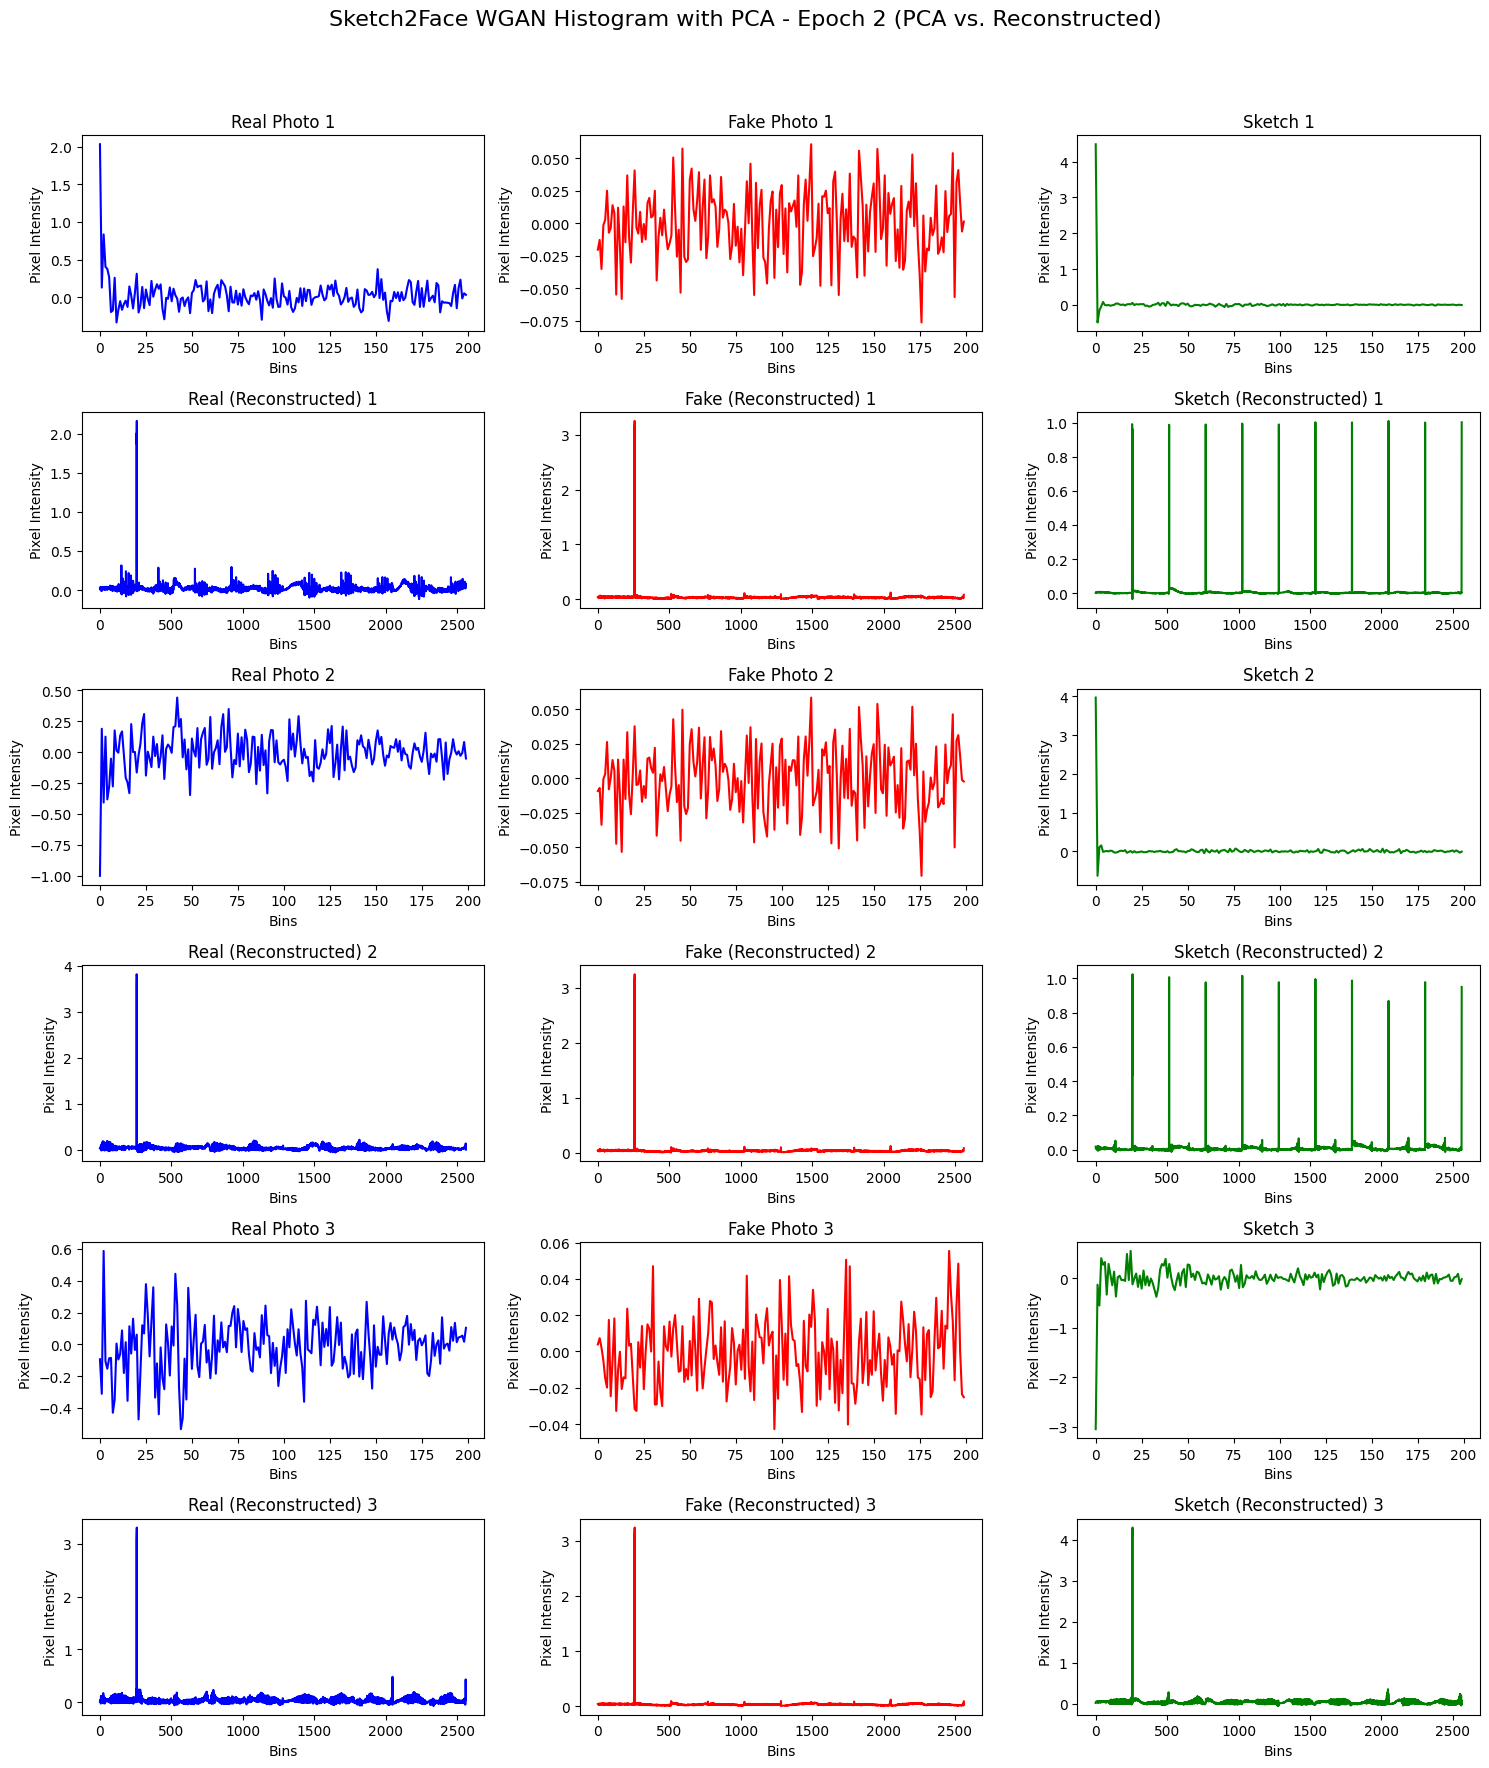

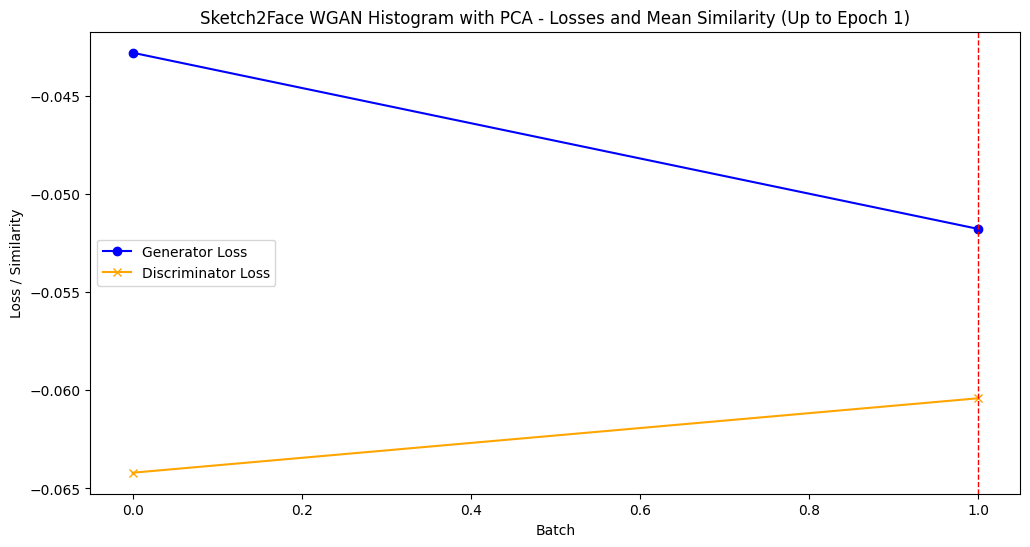

Plot saved at: Models/Sketch2Face WGAN Histogram with PCA/metrics/metrics_epoch_1.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.optimizers import RMSprop, Adam
import numpy as np
import cv2
import os

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import numpy as np
import os

def summarize_performance_with_pca(step, g_model, d_model, data, model_name, pca_photo, pca_sketch, target_dir='', n_samples=3):
    sketch_vectors, photo_vectors, photo_filenames = data

    idx = np.random.randint(0, len(sketch_vectors), n_samples)
    selected_sketches = sketch_vectors[idx]
    selected_real_photos = photo_vectors[idx]
    selected_filenames = [photo_filenames[i] for i in idx]

    fake_features = g_model.predict(selected_sketches)

    plt.figure(figsize=(15, 6 * n_samples))

    for i in range(n_samples):
        real_photo = selected_real_photos[i].flatten()
        fake_photo = fake_features[i].flatten()
        sketch = selected_sketches[i].flatten()

        # Reconstruct the images using inverse PCA
        real_photo_reconstructed = pca_photo.inverse_transform([real_photo]).flatten()
        fake_photo_reconstructed = pca_photo.inverse_transform([fake_photo]).flatten()
        sketch_reconstructed = pca_sketch.inverse_transform([sketch]).flatten()

        # Plot original PCA images in the first row
        plt.subplot(n_samples * 2, 3, 1 + i * 6)
        plt.plot(real_photo, color='blue')
        plt.title(f'Real Photo {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        plt.subplot(n_samples * 2, 3, 2 + i * 6)
        plt.plot(fake_photo, color='red')
        plt.title(f'Fake Photo {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        plt.subplot(n_samples * 2, 3, 3 + i * 6)
        plt.plot(sketch, color='green')
        plt.title(f'Sketch {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        # Plot reconstructed images directly below the originals
        plt.subplot(n_samples * 2, 3, 4 + i * 6)
        plt.plot(real_photo_reconstructed, color='blue')
        plt.title(f'Real (Reconstructed) {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        plt.subplot(n_samples * 2, 3, 5 + i * 6)
        plt.plot(fake_photo_reconstructed, color='red')
        plt.title(f'Fake (Reconstructed) {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

        plt.subplot(n_samples * 2, 3, 6 + i * 6)
        plt.plot(sketch_reconstructed, color='green')
        plt.title(f'Sketch (Reconstructed) {i + 1}')
        plt.xlabel('Bins')
        plt.ylabel('Pixel Intensity')

    plt.suptitle(f'{model_name} - Epoch {step + 1} (PCA vs. Reconstructed)', fontsize=16)

    # Adjust layout to add space between the suptitle and the plots
    plt.subplots_adjust(top=0.9)  # Adjust this value as needed

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the rectangle to ensure the title fits
    plt.show()

    # Save the plot and models (same as before)
    if target_dir:
        os.makedirs(target_dir, exist_ok=True)
        filename = f'{model_name}_pca_summary_epoch_{step + 1}.png'
        plt.savefig(os.path.join(target_dir, filename), dpi=300)
    plt.close()

    g_model.save(os.path.join(target_dir, f'generator_epoch_{step + 1}.h5'))
    d_model.save(os.path.join(target_dir, f'discriminator_epoch_{step + 1}.h5'))

def plot_metrics(generator_losses=None, discriminator_losses=None, mean_similarities=None,
                 batch_count=0, epoch=0, model_name='', target_dir=''):
    """
    Update the loss and similarity values, and generate a plot that accumulates over batches.
    A vertical line will separate the epochs for better distinction.

    Parameters:
    - generator_losses: List of generator losses up to the current batch (optional).
    - discriminator_losses: List of discriminator losses up to the current batch (optional).
    - mean_similarities: List of mean similarities up to the current batch (optional).
    - batch_count: The current batch count.
    - epoch: The current epoch.
    - model_name: Name of the model for saving the plot.
    - target_dir: Directory to save the plot.
    """

    # Check if there's any data to plot
    if generator_losses is None and discriminator_losses is None and mean_similarities is None:
        print("No data provided to plot.")
        return

    # Set up the plot
    plt.figure(figsize=(12, 6))

    # Plot Generator Loss if provided
    if generator_losses is not None:
        plt.plot(range(batch_count), generator_losses, 'o-', label='Generator Loss', color='blue')

    # Plot Discriminator Loss if provided
    if discriminator_losses is not None:
        plt.plot(range(batch_count), discriminator_losses, 'x-', label='Discriminator Loss', color='orange')

    # Plot Mean Similarity if provided
    if mean_similarities is not None:
        plt.plot(range(batch_count), mean_similarities, 's-', label='Mean Similarity', color='green')

    # Add title and labels
    plt.title(f'{model_name} - Losses and Mean Similarity (Up to Epoch {epoch})')
    plt.xlabel('Batch')
    plt.ylabel('Loss / Similarity')

    # Show legend
    plt.legend()

    # Add vertical lines to separate epochs
    for e in range(1, epoch + 1):
        plt.axvline(x=e * (batch_count // (epoch + 1)), color='red', linestyle='--', linewidth=1)

    # Ensure the target directory exists
    if target_dir and not os.path.exists(target_dir):
        os.makedirs(target_dir)

    # Save the plot
    plot_path = os.path.join(target_dir, f"metrics_epoch_{epoch}.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

    print(f"Plot saved at: {plot_path}")

# Wasserstein loss function
def wasserstein_loss(y_true, y_pred):
    return tf.reduce_mean(y_true * y_pred)

# Generator Model using U-Net architecture
def build_unet_generator(input_dim, output_dim):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(512, activation=None)(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Reshape((16, 16, 2))(x)

    # Downsampling path
    conv1 = layers.Conv2D(64, kernel_size=3, padding='same')(x)
    conv1 = layers.LeakyReLU(alpha=0.2)(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(128, kernel_size=3, padding='same')(pool1)
    conv2 = layers.LeakyReLU(alpha=0.2)(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    # Bottleneck
    bottleneck = layers.Conv2D(256, kernel_size=3, padding='same')(pool2)
    bottleneck = layers.LeakyReLU(alpha=0.2)(bottleneck)
    bottleneck = layers.BatchNormalization()(bottleneck)

    # Upsampling path
    up2 = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same')(bottleneck)
    up2 = layers.concatenate([up2, conv2])
    up2 = layers.Conv2D(128, kernel_size=3, padding='same')(up2)
    up2 = layers.LeakyReLU(alpha=0.2)(up2)
    up2 = layers.BatchNormalization()(up2)

    up1 = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same')(up2)
    up1 = layers.concatenate([up1, conv1])
    up1 = layers.Conv2D(64, kernel_size=3, padding='same')(up1)
    up1 = layers.LeakyReLU(alpha=0.2)(up1)
    up1 = layers.BatchNormalization()(up1)

    outputs = layers.Conv2DTranspose(2, kernel_size=3, padding='same')(up1)
    outputs = layers.Flatten()(outputs)
    outputs = layers.Dense(output_dim, activation='tanh')(outputs)

    return Model(inputs, outputs)

# Discriminator Model
def build_wgan_discriminator(input_dim):
    model = Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(256, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(128, activation=None),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(1, activation=None)  # No activation for WGAN
    ])
    return model

# Apply PCA transformation to extracted features
def extract_features_with_pca(image_folder, n_components=200):
    all_feature_vectors = []
    filenames = []

    for filename in os.listdir(image_folder):
        if filename.endswith('.png') or filename.endswith('.jpg'):
            face_image = cv2.imread(os.path.join(image_folder, filename), cv2.IMREAD_GRAYSCALE)
            if face_image is None:
                continue

            # Histogram Equalization
            equalized_image = cv2.equalizeHist(face_image)

            # Compute the Global Histogram
            global_hist = cv2.calcHist([equalized_image], [0], None, [256], [0, 256])
            global_hist = cv2.normalize(global_hist, global_hist).flatten()

            # Extract Features from Specific Histogram Regions
            low_region_hist = np.sum(global_hist[:85])  # Low intensity range
            mid_region_hist = np.sum(global_hist[85:170])  # Mid intensity range
            high_region_hist = np.sum(global_hist[170:])  # High intensity range

            feature_vector = np.array([low_region_hist, mid_region_hist, high_region_hist])

            # Local Histogram Analysis (3x3 grid)
            height, width = equalized_image.shape
            grid_size = (3, 3)
            region_height = height // grid_size[0]
            region_width = width // grid_size[1]

            local_histograms = []

            for i in range(grid_size[0]):
                for j in range(grid_size[1]):
                    roi = equalized_image[i * region_height:(i + 1) * region_height, j * region_width:(j + 1) * region_width]
                    local_hist = cv2.calcHist([roi], [0], None, [256], [0, 256])
                    local_hist = cv2.normalize(local_hist, local_hist).flatten()
                    local_histograms.append(local_hist)

            # Combine Global and Local Features
            combined_feature_vector = np.hstack([global_hist, feature_vector, *local_histograms])

            all_feature_vectors.append(combined_feature_vector)
            filenames.append(filename)

    # Convert list to numpy array
    all_feature_vectors = np.array(all_feature_vectors)

    # Apply PCA transformation
    pca = PCA(n_components=n_components)
    transformed_features = pca.fit_transform(all_feature_vectors)

    return transformed_features, filenames, pca

# Define the paths to the image datasets
photo_folder = '/content/combined/photos'  # Update with your path
sketch_folder = '/content/combined/sketches'  # Update with your path

n_components=200

# Extract PCA-transformed features from photos and sketches
photo_features, photo_filenames, pca_photo = extract_features_with_pca(photo_folder,n_components)
sketch_features, sketch_filenames, pca_sketch = extract_features_with_pca(sketch_folder,n_components)

input_dim = sketch_features.shape[1]
output_dim = photo_features.shape[1]

# Create the models
generator = build_unet_generator(input_dim, output_dim)
discriminator = build_wgan_discriminator(output_dim)

# Optimizer for the discriminator (RMSprop)
discriminator_opt = RMSprop(learning_rate=5e-5)

# Compile Discriminator with WGAN loss
discriminator.compile(loss=wasserstein_loss, optimizer=discriminator_opt)

# Build GAN Model
discriminator.trainable = False
gan_input = layers.Input(shape=(input_dim,))
generated_features = generator(gan_input)
gan_output = discriminator(generated_features)

gan = Model(gan_input, gan_output)

# Optimizer for the GAN model (Adam)
generator_opt = Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)

# Compile GAN model
gan.compile(loss=wasserstein_loss, optimizer=generator_opt)

# Training loop
epochs = 10000  # Adjust the number of epochs
batch_size = 32  # Adjust the batch size
save_interval = 1  # Adjust the save interval
model_name = 'Sketch2Face WGAN Histogram with PCA'

# Initialize lists to keep track of losses and similarities
generator_losses = []
discriminator_losses = []
mean_similarities = []

for epoch in range(epochs):
    # Train Discriminator
    idx = np.random.randint(0, photo_features.shape[0], batch_size)
    real_features = photo_features[idx]
    fake_features = generator.predict(sketch_features[idx])

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_features, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_features, fake_labels)

    d_loss = 0.5 * (d_loss_real + d_loss_fake)

    # Train Generator
    g_loss,_ = gan.train_on_batch(sketch_features[idx], real_labels)

    # Store losses for plotting
    generator_losses.append(g_loss)
    discriminator_losses.append(d_loss)

    # Print progress
    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {d_loss:.4f}] [G loss: {g_loss:.4f}]")

    # Save generator model and summarize performance at intervals
    if epoch % save_interval == 0:
        summarize_performance_with_pca(
            step=epoch,
            g_model=generator,
            d_model=discriminator,
            data=(sketch_features, photo_features, photo_filenames),
            model_name=model_name,
            pca_photo=pca_photo,
            pca_sketch=pca_sketch,
            target_dir=f'Models/{model_name}/output_images_pca/',
            n_samples=3
        )

    # Plot metrics at the end of each epoch
    if epoch % save_interval == 0:
        plot_metrics(
            generator_losses=generator_losses,
            discriminator_losses=discriminator_losses,
            batch_count=len(generator_losses),
            epoch=epoch,
            model_name=model_name,
            target_dir=f'Models/{model_name}/metrics/'
        )